# Entendimento do Problema de Negócio e Dados

---

## Contexto de Negócio

Uma empresa de telecomunicações enfrenta o desafio do **churn** — o cancelamento ou abandono de clientes que deixam de utilizar os serviços contratados. Reter um cliente existente é significativamente mais barato do que adquirir um novo, tornando esse problema estratégico para o negócio.

O objetivo deste projeto é **prever quais clientes têm maior probabilidade de cancelar o serviço** com base em características demográficas, contratuais e de uso. Com essa informação, a empresa pode agir preventivamente: oferecer promoções, melhorar o atendimento ou ajustar planos para os clientes com alto risco de churn.

### Tipo de Problema
- **Classificação binária supervisionada**
- **Variável-alvo:** `Churn` — se o cliente cancelou (`Yes`) ou não (`No`) o serviço

---

## Dicionário de Dados

| Coluna | Tipo | Descrição |
|---|---|---|
| `id` | int | Identificador único do cliente |
| `gender` | categórico | Gênero do cliente (`Male` / `Female`) |
| `SeniorCitizen` | int (0/1) | Indica se o cliente é idoso (`1` = Sim, `0` = Não) |
| `Partner` | categórico | Indica se o cliente possui parceiro(a) (`Yes` / `No`) |
| `Dependents` | categórico | Indica se o cliente possui dependentes (`Yes` / `No`) |
| `tenure` | int | Número de meses que o cliente está com a empresa |
| `PhoneService` | categórico | Indica se o cliente possui serviço de telefonia (`Yes` / `No`) |
| `MultipleLines` | categórico | Indica se o cliente possui múltiplas linhas telefônicas (`Yes` / `No` / `No phone service`) |
| `InternetService` | categórico | Tipo de serviço de internet contratado (`DSL` / `Fiber optic` / `No`) |
| `OnlineSecurity` | categórico | Indica se o cliente possui serviço de segurança online (`Yes` / `No` / `No internet service`) |
| `OnlineBackup` | categórico | Indica se o cliente possui serviço de backup online (`Yes` / `No` / `No internet service`) |
| `DeviceProtection` | categórico | Indica se o cliente possui proteção de dispositivos (`Yes` / `No` / `No internet service`) |
| `TechSupport` | categórico | Indica se o cliente possui suporte técnico (`Yes` / `No` / `No internet service`) |
| `StreamingTV` | categórico | Indica se o cliente possui serviço de streaming de TV (`Yes` / `No` / `No internet service`) |
| `StreamingMovies` | categórico | Indica se o cliente possui serviço de streaming de filmes (`Yes` / `No` / `No internet service`) |
| `Contract` | categórico | Tipo de contrato do cliente (`Month-to-month` / `One year` / `Two year`) |
| `PaperlessBilling` | categórico | Indica se o cliente utiliza fatura digital (`Yes` / `No`) |
| `PaymentMethod` | categórico | Método de pagamento utilizado (`Electronic check` / `Mailed check` / `Bank transfer (automatic)` / `Credit card (automatic)`) |
| `MonthlyCharges` | float | Valor cobrado mensalmente do cliente (em dólares) |
| `TotalCharges` | float | Valor total cobrado ao longo do relacionamento com o cliente (em dólares) |
| `Churn` | categórico | **Variável-alvo** — indica se o cliente cancelou o serviço (`Yes` / `No`) |

---

## Hipóteses Iniciais de Negócio

- Clientes com contratos mensais (`Month-to-month`) tendem a cancelar mais, pois não possuem vínculo de longo prazo.
- Clientes com maior `tenure` (tempo de permanência) tendem a ser mais fiéis.
- Clientes idosos (`SeniorCitizen = 1`) podem apresentar taxas de churn diferentes da média.
- `MonthlyCharges` elevado pode ser um fator de insatisfação e levar ao cancelamento.
- A ausência de serviços adicionais (segurança, suporte técnico) pode indicar menor engajamento e maior risco de churn.


# Imports

In [1]:
import pandas as pd
import numpy as np

# Data Load

In [2]:
df = pd.read_csv('../data/train.csv')

# 1.0 Descrição dos Dados

In [3]:
df1 = df.copy()

## 1.1 Dimensão dos Dados

In [4]:
print('Quantidade de Linhas: ', df1.shape[0])
print('Quantidade de Colunas: ', df1.shape[1])

Quantidade de Linhas:  594194
Quantidade de Colunas:  21


## 1.2 Tipo dos Dados

In [5]:
df1.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## 1.3 Check NA

In [6]:
df1.isna().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 1.4 Estatísticas Descritivas

In [7]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'] )
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'] )

In [8]:
# Central Tendency - mean, meadina 
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T 
d2 = pd.DataFrame( num_attributes.apply( min ) ).T 
d3 = pd.DataFrame( num_attributes.apply( max ) ).T 
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() ) ).T 
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T 
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T 

# concatenar
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,0.00,594193.00,594193.0,297096.500000,297096.50,171529.032925,-1.404148e-15,-1.200000
1,SeniorCitizen,0.00,1.00,1.0,0.114102,0.00,0.317936,2.427526e+00,3.892894
2,tenure,1.00,72.00,71.0,36.577258,35.00,25.061901,6.305030e-02,-1.487182
3,MonthlyCharges,18.25,118.75,100.5,65.866223,74.10,31.067418,-2.894857e-01,-1.277955
4,TotalCharges,18.80,8684.80,8666.0,2494.377057,1433.65,2353.914730,9.091694e-01,-0.446287


# 2.0 Análise Exlporatória de Dados

In [9]:
df2 = df1.copy()

## 2.1 Análise Univariada

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13


### 2.1.1 Análise Univariada — Variáveis Categóricas

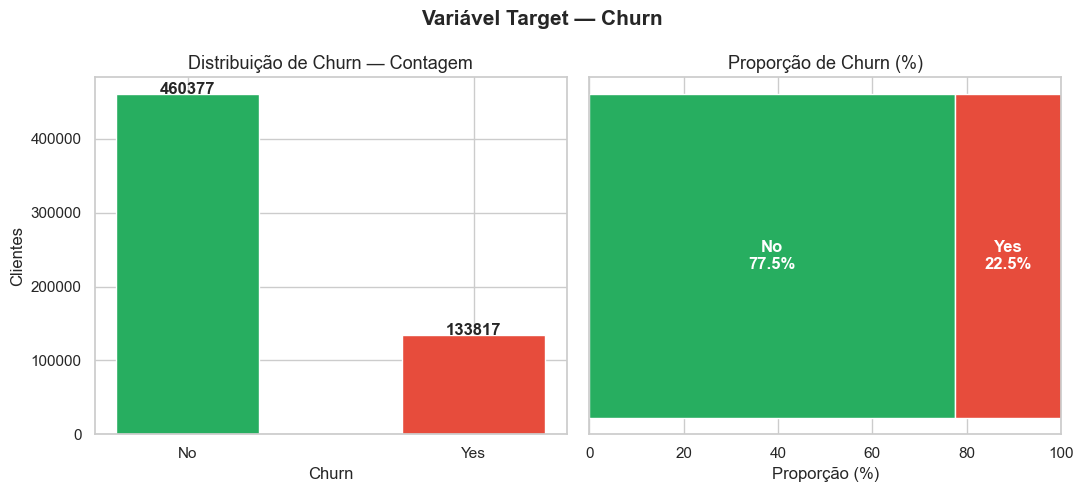

In [11]:

# Distribuição da variável target: Churn
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

churn_counts = df2['Churn'].value_counts()
colors = ['#27ae60', '#e74c3c']

# Contagem
axes[0].bar(churn_counts.index.tolist(), churn_counts.values.tolist(), color=colors, edgecolor='white', width=0.5)
for i, (cat, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribuição de Churn — Contagem')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Clientes')

# Proporção % — barra horizontal empilhada (substitui pie() por incompatibilidade matplotlib/numpy)
pct = churn_counts / churn_counts.sum() * 100
vals  = pct.values.tolist()
lbls  = pct.index.tolist()
left  = 0
for val, color, lbl in zip(vals, colors, lbls):
    axes[1].barh([''], [val], left=[left], color=color, edgecolor='white', height=0.5)
    axes[1].text(left + val / 2, 0, f'{lbl}\n{val:.1f}%',
                 ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    left += val
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Proporção (%)')
axes[1].set_title('Proporção de Churn (%)')
axes[1].set_yticks([])

plt.suptitle('Variável Target — Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# Insight: dataset desbalanceado — ~26% cancelaram. Importante considerar métricas além de acurácia.


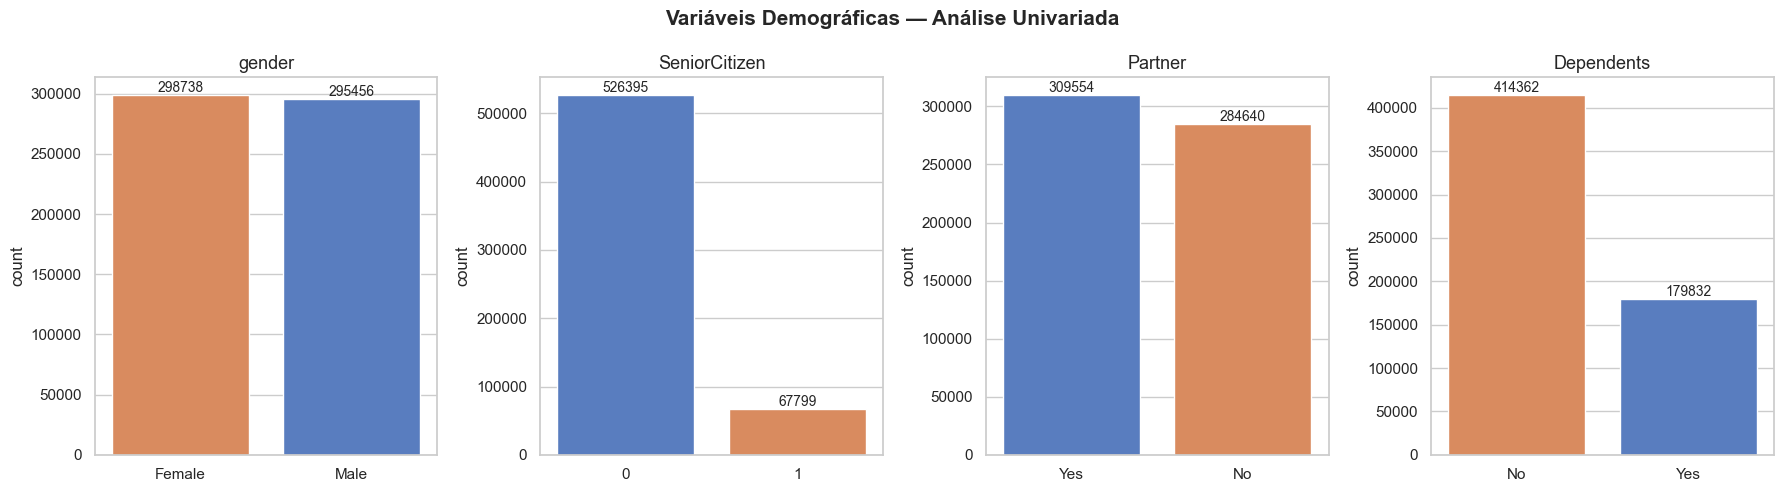

In [12]:

# Variáveis demográficas: gender, SeniorCitizen, Partner, Dependents
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

demo_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
for ax, col in zip(axes, demo_vars):
    order = df2[col].value_counts().index.tolist()
    sns.countplot(data=df2, x=col, hue=col, palette='muted', ax=ax, order=order, legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    for p in ax.patches:
        h = float(p.get_height())
        if h > 0:
            ax.annotate(f'{int(h)}',
                        (float(p.get_x() + p.get_width() / 2.), h),
                        ha='center', va='bottom', fontsize=10)

plt.suptitle('Variáveis Demográficas — Análise Univariada', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


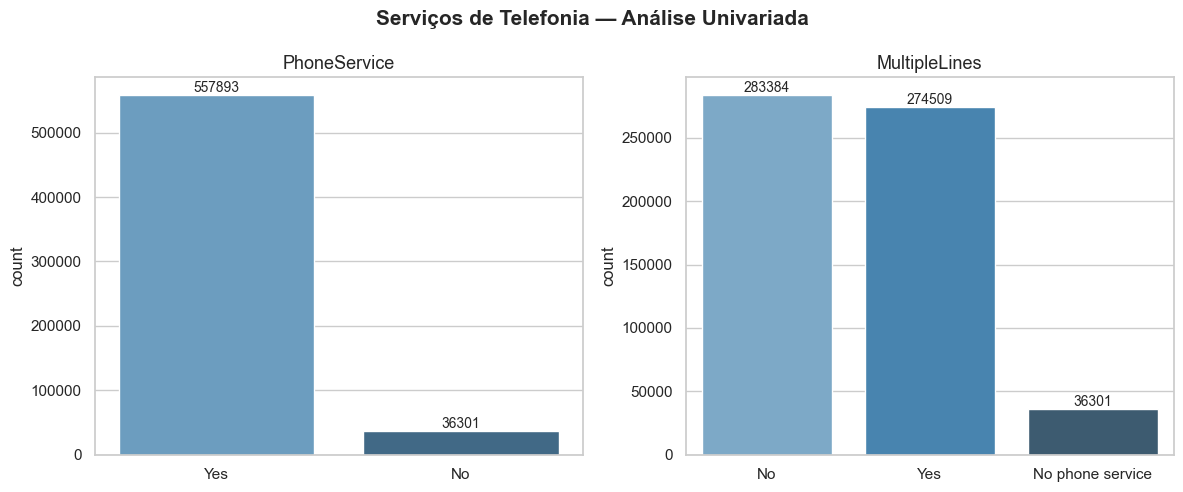

In [13]:

# Serviços de telefonia: PhoneService e MultipleLines
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['PhoneService', 'MultipleLines']):
    order = df2[col].value_counts().index.tolist()
    sns.countplot(data=df2, x=col, hue=col, palette='Blues_d', ax=ax, order=order, legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    for p in ax.patches:
        h = float(p.get_height())
        if h > 0:
            ax.annotate(f'{int(h)}',
                        (float(p.get_x() + p.get_width() / 2.), h),
                        ha='center', va='bottom', fontsize=10)

plt.suptitle('Serviços de Telefonia — Análise Univariada', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


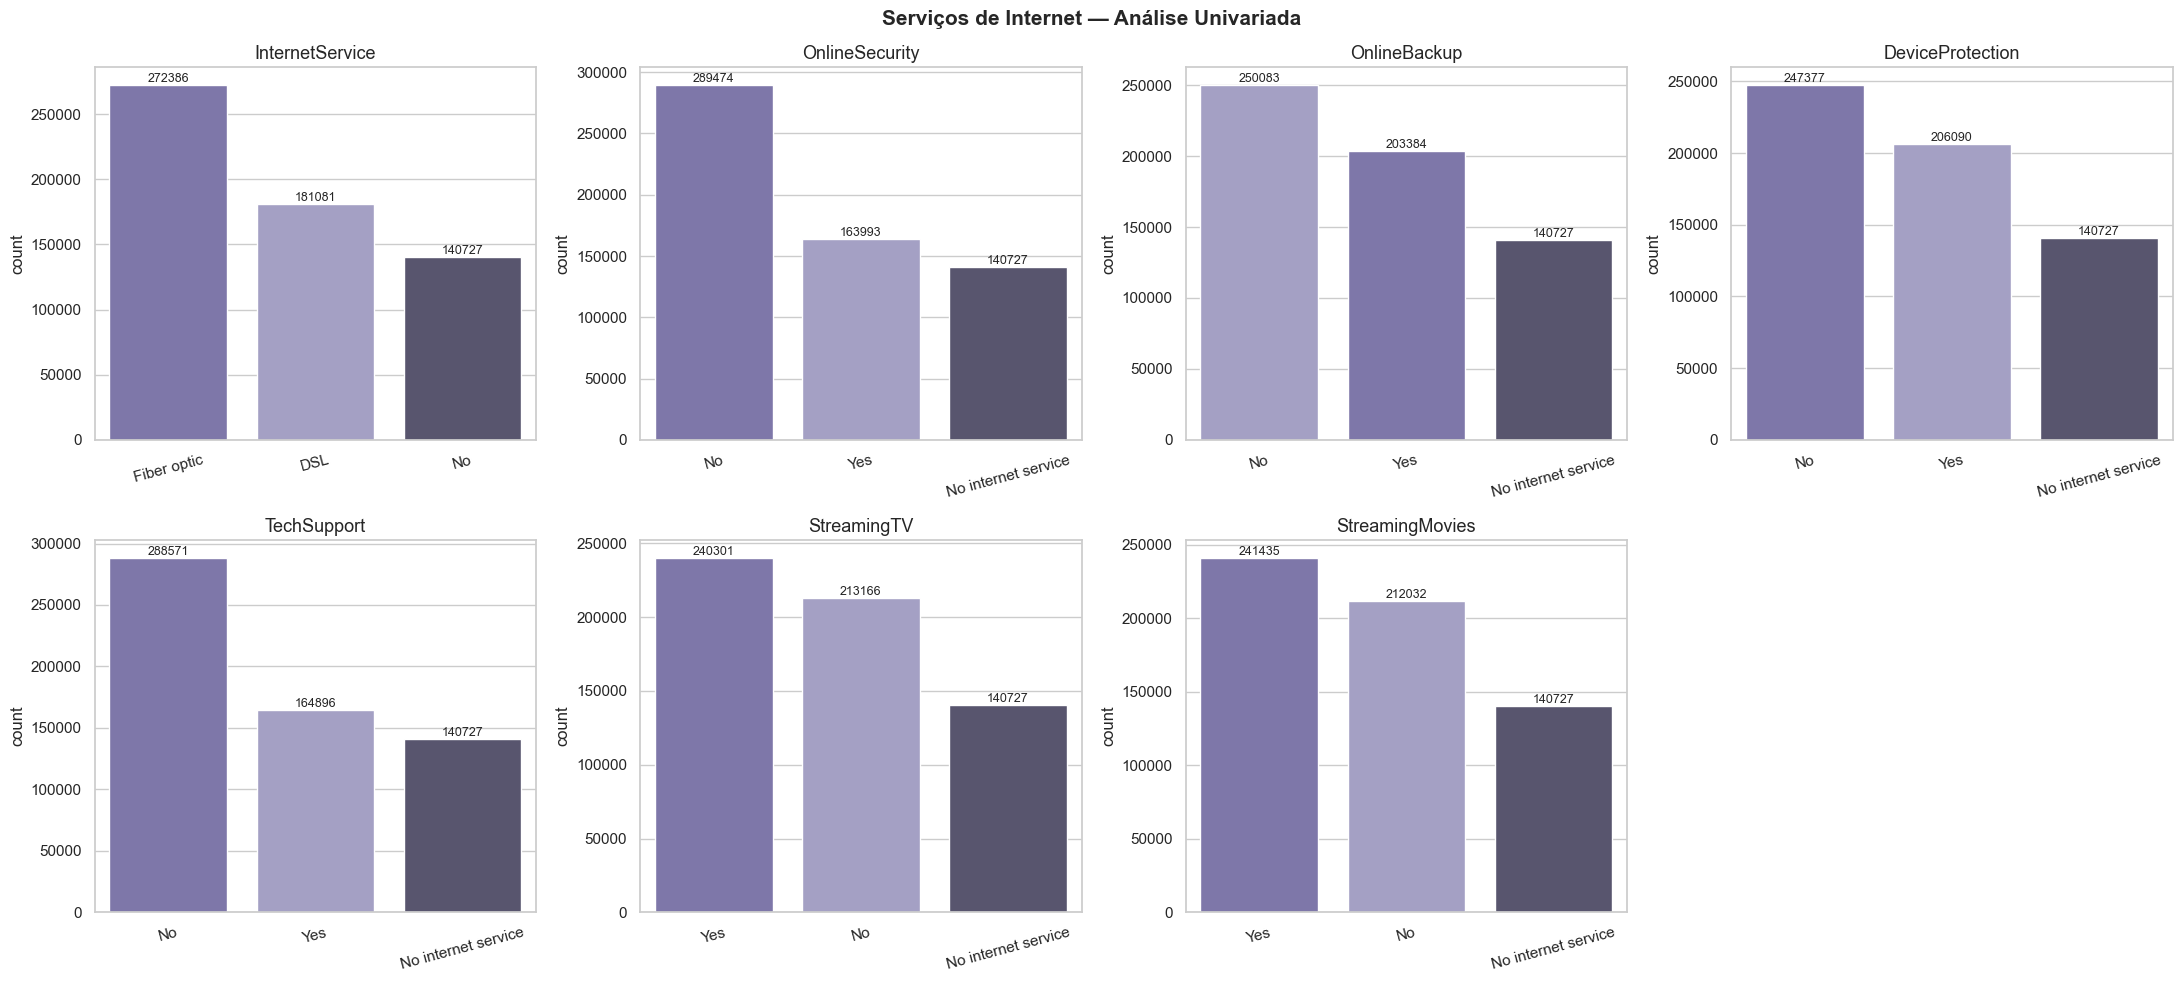

In [14]:

# Serviços de internet: InternetService + serviços adicionais
internet_vars = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(internet_vars):
    order = df2[col].value_counts().index.tolist()
    sns.countplot(data=df2, x=col, hue=col, palette='Purples_d', ax=axes[i], order=order, legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    for p in axes[i].patches:
        h = float(p.get_height())
        if h > 0:
            axes[i].annotate(f'{int(h)}',
                             (float(p.get_x() + p.get_width() / 2.), h),
                             ha='center', va='bottom', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Serviços de Internet — Análise Univariada', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


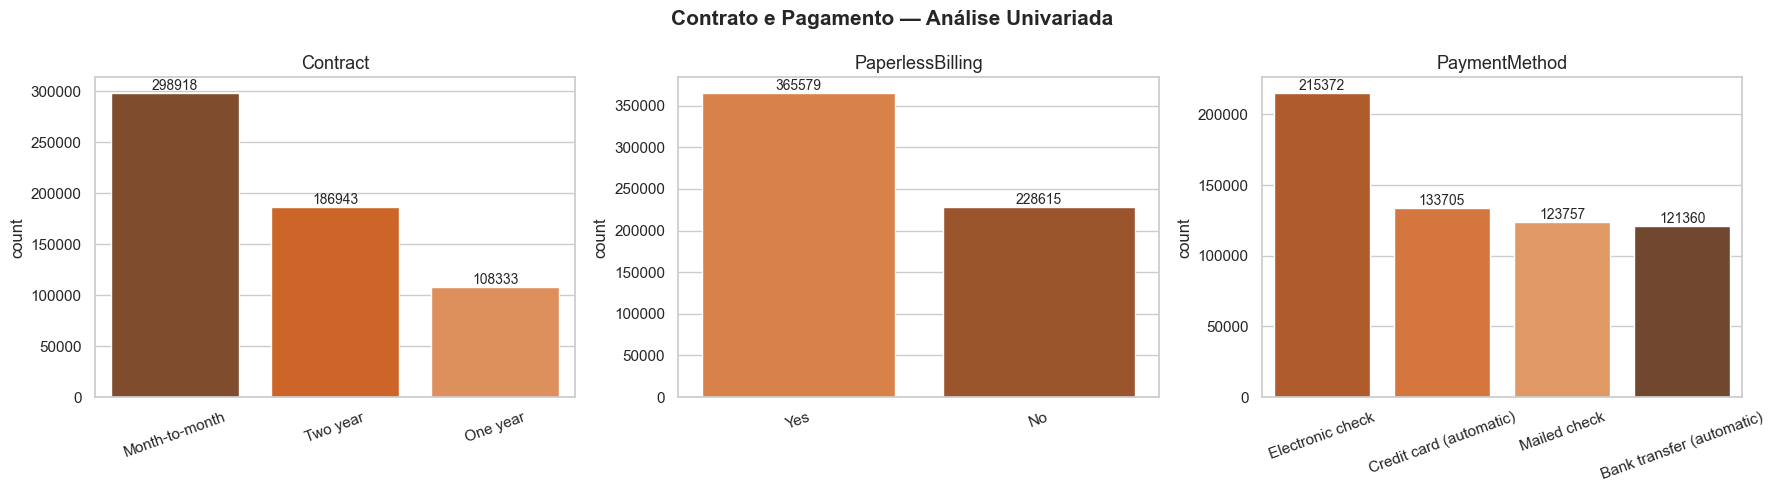

In [15]:

# Variáveis contratuais e de pagamento: Contract, PaperlessBilling, PaymentMethod
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Contract', 'PaperlessBilling', 'PaymentMethod']):
    order = df2[col].value_counts().index.tolist()
    sns.countplot(data=df2, x=col, hue=col, palette='Oranges_d', ax=ax, order=order, legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    for p in ax.patches:
        h = float(p.get_height())
        if h > 0:
            ax.annotate(f'{int(h)}',
                        (float(p.get_x() + p.get_width() / 2.), h),
                        ha='center', va='bottom', fontsize=10)

plt.suptitle('Contrato e Pagamento — Análise Univariada', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.1.2 Análise Univariada — Variáveis Numéricas

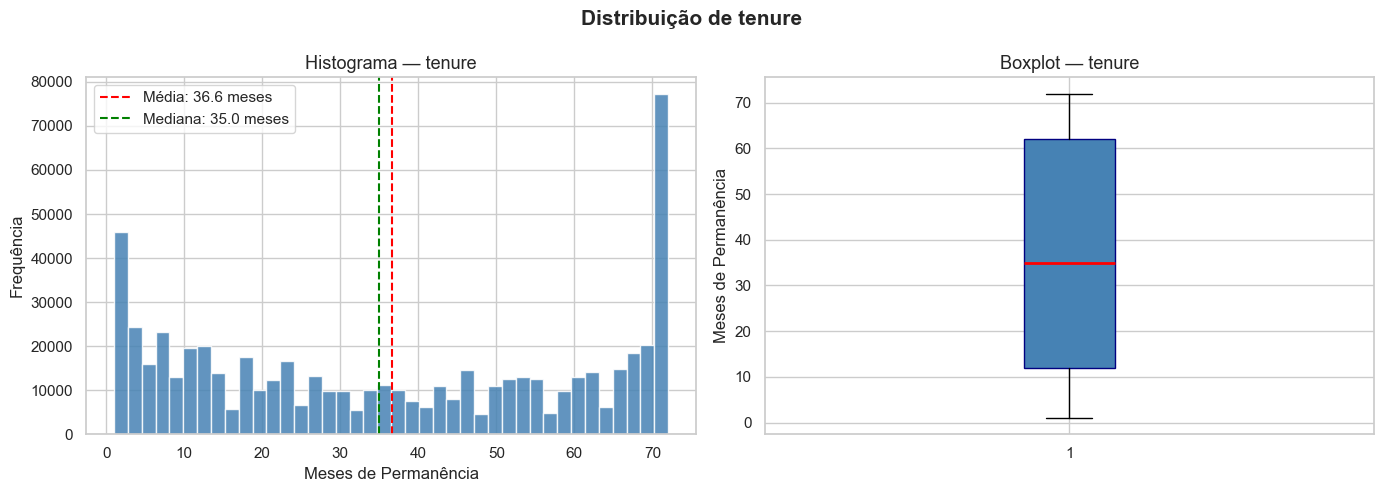

In [16]:

# Distribuição de tenure (meses de permanência com a empresa)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df2['tenure'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df2['tenure'].mean(), color='red', linestyle='--',
                label=f"Média: {df2['tenure'].mean():.1f} meses")
axes[0].axvline(df2['tenure'].median(), color='green', linestyle='--',
                label=f"Mediana: {df2['tenure'].median():.1f} meses")
axes[0].set_title('Histograma — tenure')
axes[0].set_xlabel('Meses de Permanência')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df2['tenure'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — tenure')
axes[1].set_ylabel('Meses de Permanência')

plt.suptitle('Distribuição de tenure', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# Insight: distribuição bimodal — muitos clientes novos (1 mês) e clientes muito fiéis (72 meses).


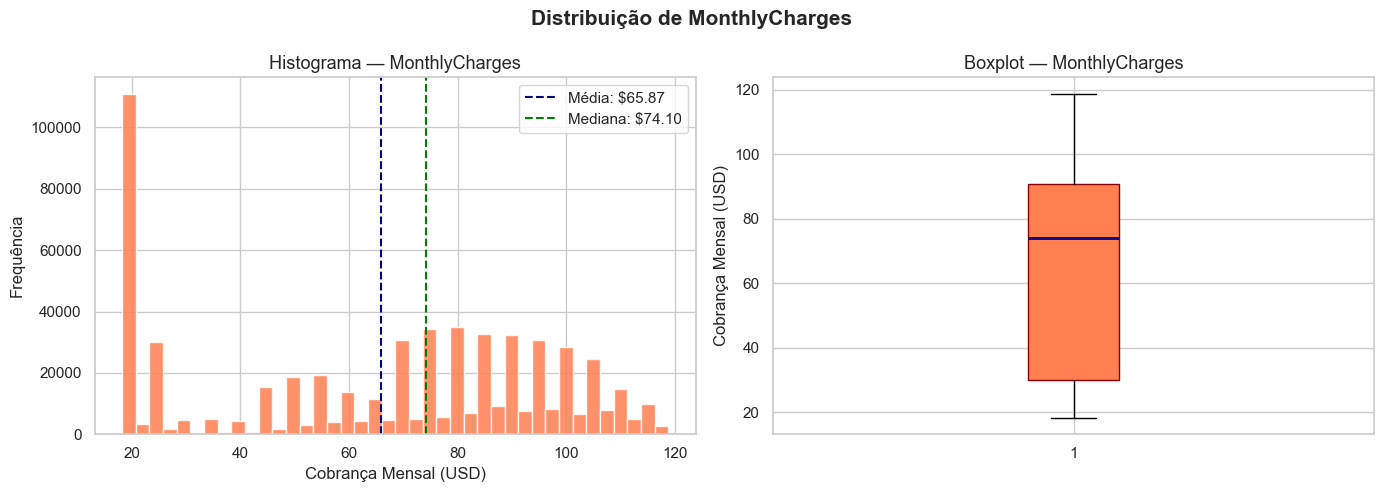

In [17]:

# Distribuição de MonthlyCharges (cobrança mensal)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df2['MonthlyCharges'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(df2['MonthlyCharges'].mean(), color='navy', linestyle='--',
                label=f"Média: ${df2['MonthlyCharges'].mean():.2f}")
axes[0].axvline(df2['MonthlyCharges'].median(), color='green', linestyle='--',
                label=f"Mediana: ${df2['MonthlyCharges'].median():.2f}")
axes[0].set_title('Histograma — MonthlyCharges')
axes[0].set_xlabel('Cobrança Mensal (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df2['MonthlyCharges'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='coral', color='darkred'),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_title('Boxplot — MonthlyCharges')
axes[1].set_ylabel('Cobrança Mensal (USD)')

plt.suptitle('Distribuição de MonthlyCharges', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# Insight: pico em planos mais baratos (~$20) e concentração em planos mais caros (fibra óptica?).


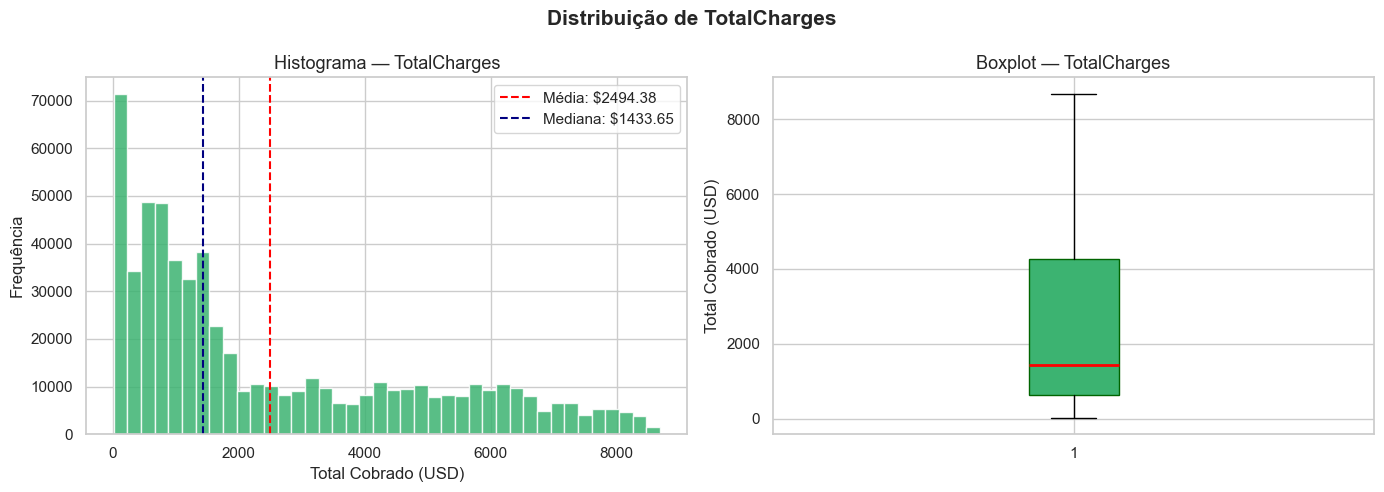

In [18]:

# Distribuição de TotalCharges (total cobrado ao longo do relacionamento)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tc = df2['TotalCharges'].dropna()
axes[0].hist(tc, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(tc.mean(), color='red', linestyle='--', label=f"Média: ${tc.mean():.2f}")
axes[0].axvline(tc.median(), color='navy', linestyle='--', label=f"Mediana: ${tc.median():.2f}")
axes[0].set_title('Histograma — TotalCharges')
axes[0].set_xlabel('Total Cobrado (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(tc, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', color='darkgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — TotalCharges')
axes[1].set_ylabel('Total Cobrado (USD)')

plt.suptitle('Distribuição de TotalCharges', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
# Insight: distribuição assimétrica à direita — a maioria dos clientes tem baixo total pago (novos?).


## 2.2 Análise Bivariada

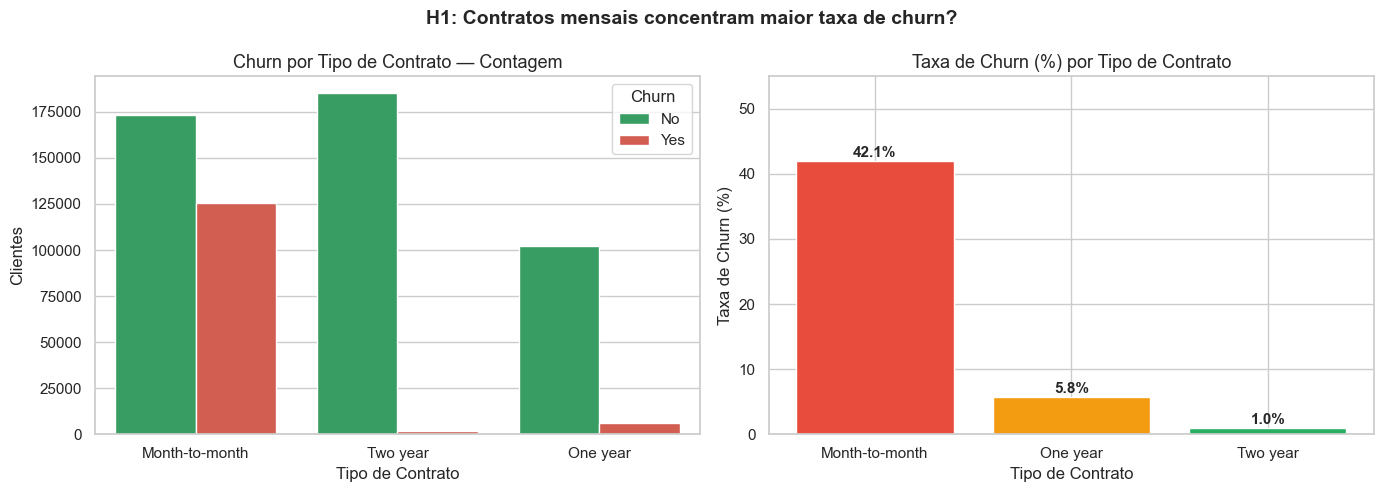

In [19]:

# H1: Tipo de contrato influencia o churn?
# Hipótese: clientes com contrato mensal (Month-to-month) têm maior taxa de churn por não terem vínculo de longo prazo.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df2, x='Contract', hue='Churn', palette=['#27ae60', '#e74c3c'],
              ax=axes[0], order=df2['Contract'].value_counts().index)
axes[0].set_title('Churn por Tipo de Contrato — Contagem')
axes[0].set_xlabel('Tipo de Contrato')
axes[0].set_ylabel('Clientes')
axes[0].legend(title='Churn')

churn_rate = (df2.groupby('Contract')['Churn']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .reset_index()
              .rename(columns={'Churn': 'Churn_Rate'})
              .sort_values('Churn_Rate', ascending=False))

cores = ['#e74c3c', '#f39c12', '#27ae60']
axes[1].bar(churn_rate['Contract'], churn_rate['Churn_Rate'], color=cores, edgecolor='white')
for i, v in enumerate(churn_rate['Churn_Rate']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Taxa de Churn (%) por Tipo de Contrato')
axes[1].set_xlabel('Tipo de Contrato')
axes[1].set_ylabel('Taxa de Churn (%)')
axes[1].set_ylim(0, 55)

plt.suptitle('H1: Contratos mensais concentram maior taxa de churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Month-to-month churn ~43%, One year ~11%, Two year ~3%.


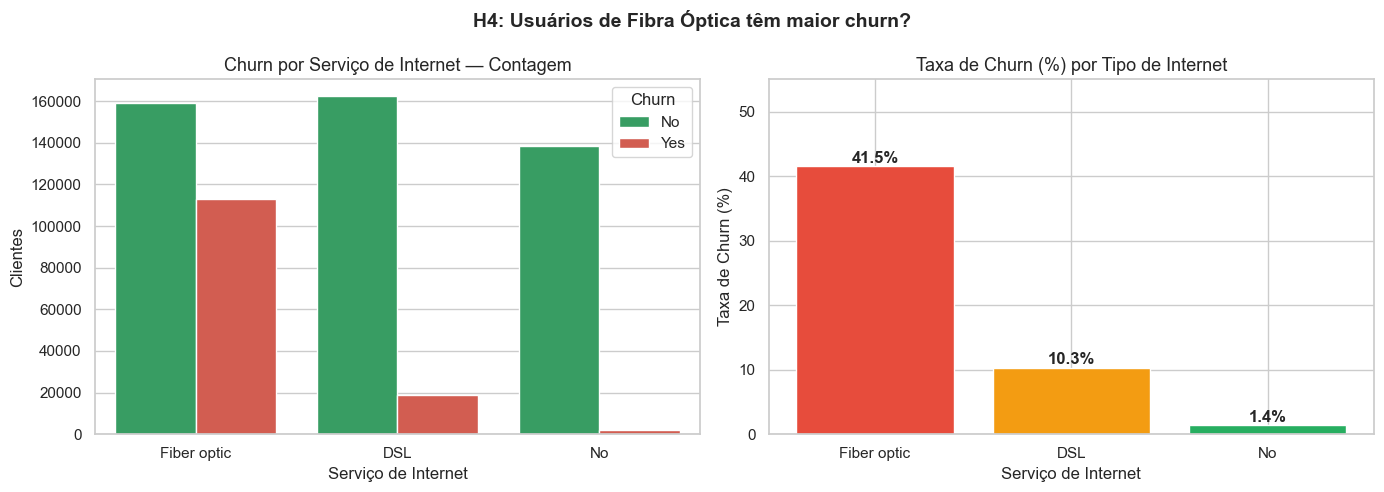

In [20]:

# H4: Tipo de serviço de internet influencia o churn?
# Nova hipótese: usuários de Fibra Óptica pagam mais e podem estar insatisfeitos com o custo-benefício.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df2, x='InternetService', hue='Churn',
              palette=['#27ae60', '#e74c3c'], ax=axes[0],
              order=df2['InternetService'].value_counts().index)
axes[0].set_title('Churn por Serviço de Internet — Contagem')
axes[0].set_xlabel('Serviço de Internet')
axes[0].set_ylabel('Clientes')
axes[0].legend(title='Churn')

churn_rate = (df2.groupby('InternetService')['Churn']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .reset_index()
              .rename(columns={'Churn': 'Churn_Rate'})
              .sort_values('Churn_Rate', ascending=False))

cores = ['#e74c3c', '#f39c12', '#27ae60']
axes[1].bar(churn_rate['InternetService'], churn_rate['Churn_Rate'],
            color=cores, edgecolor='white')
for i, v in enumerate(churn_rate['Churn_Rate']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Taxa de Churn (%) por Tipo de Internet')
axes[1].set_xlabel('Serviço de Internet')
axes[1].set_ylabel('Taxa de Churn (%)')
axes[1].set_ylim(0, 55)

plt.suptitle('H4: Usuários de Fibra Óptica têm maior churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Fiber optic ~41%, DSL ~19%, No internet ~7%. Investigar cobrança vs satisfação.


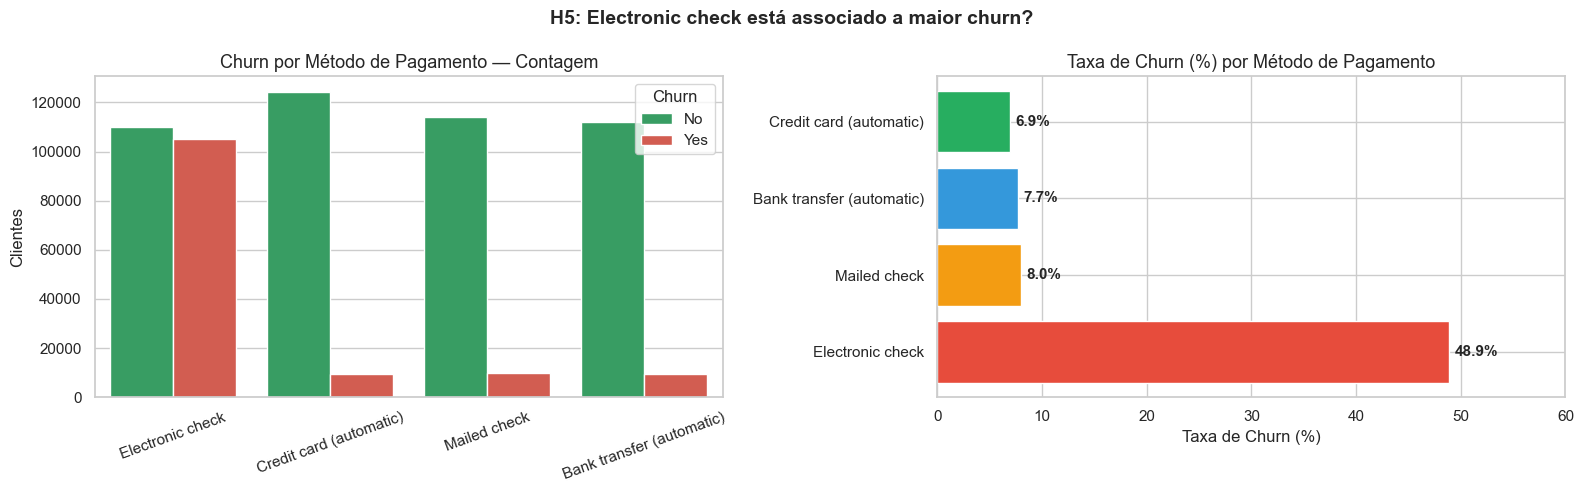

In [21]:

# H5: Método de pagamento está associado ao churn?
# Nova hipótese: Electronic check pode indicar clientes menos comprometidos ou com dificuldade financeira.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df2, x='PaymentMethod', hue='Churn',
              palette=['#27ae60', '#e74c3c'], ax=axes[0],
              order=df2['PaymentMethod'].value_counts().index)
axes[0].set_title('Churn por Método de Pagamento — Contagem')
axes[0].set_xlabel('')
axes[0].set_ylabel('Clientes')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Churn')

churn_rate = (df2.groupby('PaymentMethod')['Churn']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .reset_index()
              .rename(columns={'Churn': 'Churn_Rate'})
              .sort_values('Churn_Rate', ascending=False))

cores = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
axes[1].barh(churn_rate['PaymentMethod'], churn_rate['Churn_Rate'],
             color=cores, edgecolor='white')
for i, v in enumerate(churn_rate['Churn_Rate']):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Taxa de Churn (%) por Método de Pagamento')
axes[1].set_xlabel('Taxa de Churn (%)')
axes[1].set_xlim(0, 60)

plt.suptitle('H5: Electronic check está associado a maior churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Electronic check ~45% de churn. Pagamentos automáticos (cartão/banco) ~15-17%.


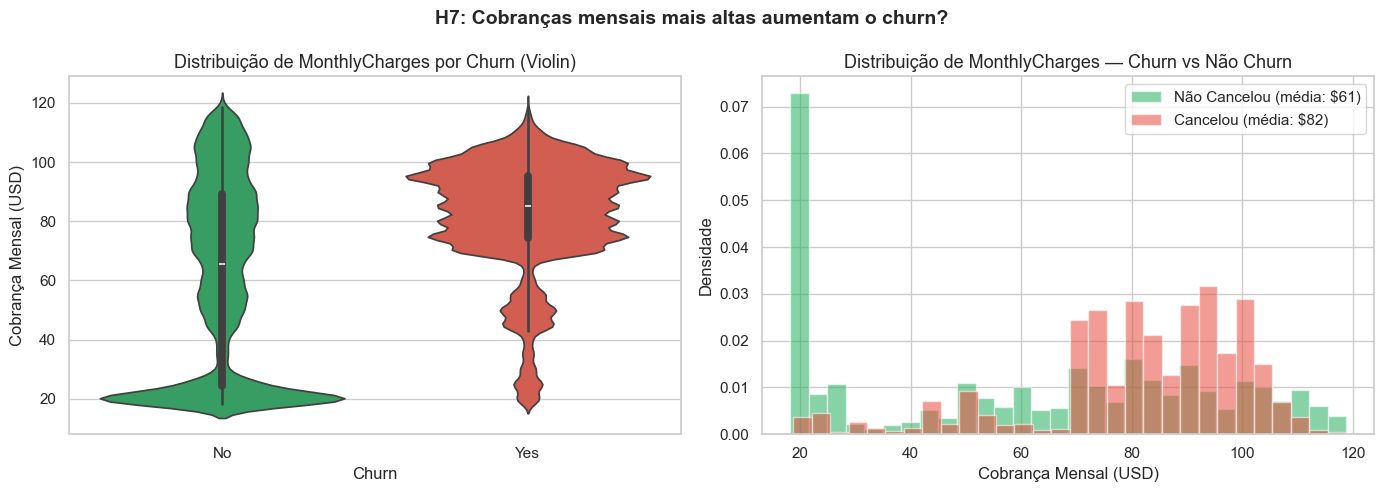

In [22]:

# H7: Cobranças mensais mais altas estão associadas a maior churn?
# Nova hipótese: custo percebido alto pode gerar insatisfação e levar ao cancelamento.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df2, x='Churn', y='MonthlyCharges',
               palette=['#27ae60', '#e74c3c'], ax=axes[0], inner='box')
axes[0].set_title('Distribuição de MonthlyCharges por Churn (Violin)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cobrança Mensal (USD)')

for churn_val, color, label in zip(['No', 'Yes'], ['#27ae60', '#e74c3c'],
                                    ['Não Cancelou', 'Cancelou']):
    subset = df2[df2['Churn'] == churn_val]['MonthlyCharges']
    axes[1].hist(subset, bins=30, alpha=0.55, color=color,
                 label=f'{label} (média: ${subset.mean():.0f})', density=True, edgecolor='white')
axes[1].set_title('Distribuição de MonthlyCharges — Churn vs Não Churn')
axes[1].set_xlabel('Cobrança Mensal (USD)')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.suptitle('H7: Cobranças mensais mais altas aumentam o churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Média MonthlyCharges Churn=Yes ~$74 vs ~$61 para não-churn. Correlação relevante.


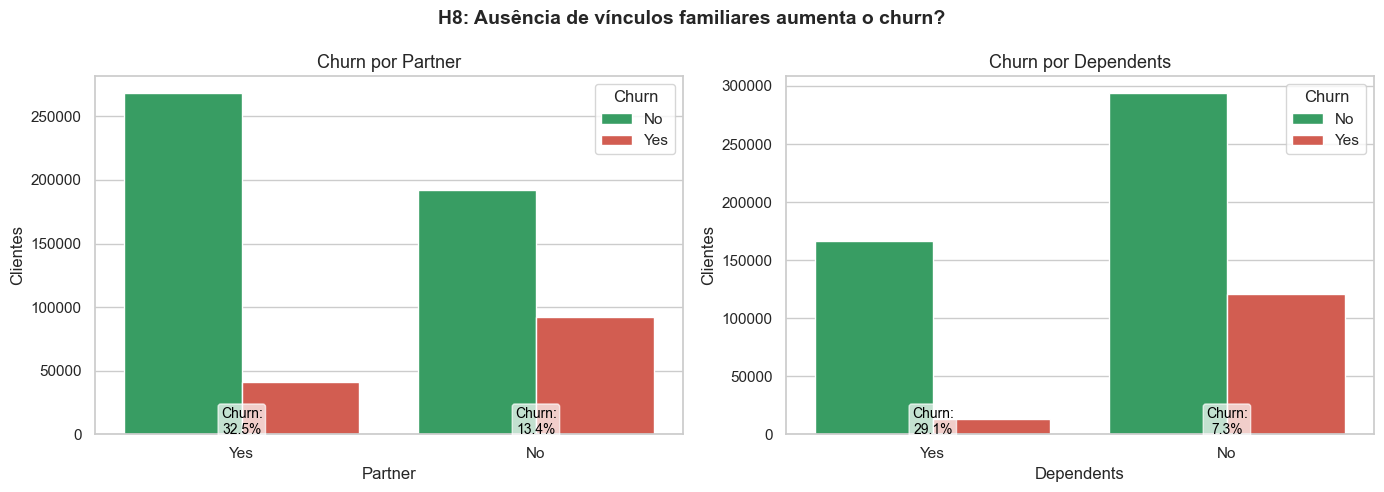

In [23]:

# H8: Clientes sem vínculos familiares (Partner, Dependents) têm mais churn?
# Nova hipótese: clientes solteiros ou sem dependentes podem ser mais propensos a cancelar.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Partner', 'Dependents']):
    churn_rate = (df2.groupby(col)['Churn']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .reset_index()
                  .rename(columns={'Churn': 'Churn_Rate'}))

    sns.countplot(data=df2, x=col, hue='Churn', palette=['#27ae60', '#e74c3c'], ax=ax)
    ax.set_title(f'Churn por {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Clientes')
    ax.legend(title='Churn')

    # Anotar taxa de churn sobre cada grupo
    for i, row in enumerate(churn_rate.itertuples()):
        ax.text(i, 150, f'Churn:\n{row.Churn_Rate:.1f}%',
                ha='center', fontsize=10, color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.suptitle('H8: Ausência de vínculos familiares aumenta o churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Sem partner: ~33% churn; com partner: ~20%. Sem dependentes: ~31%; com: ~15%.


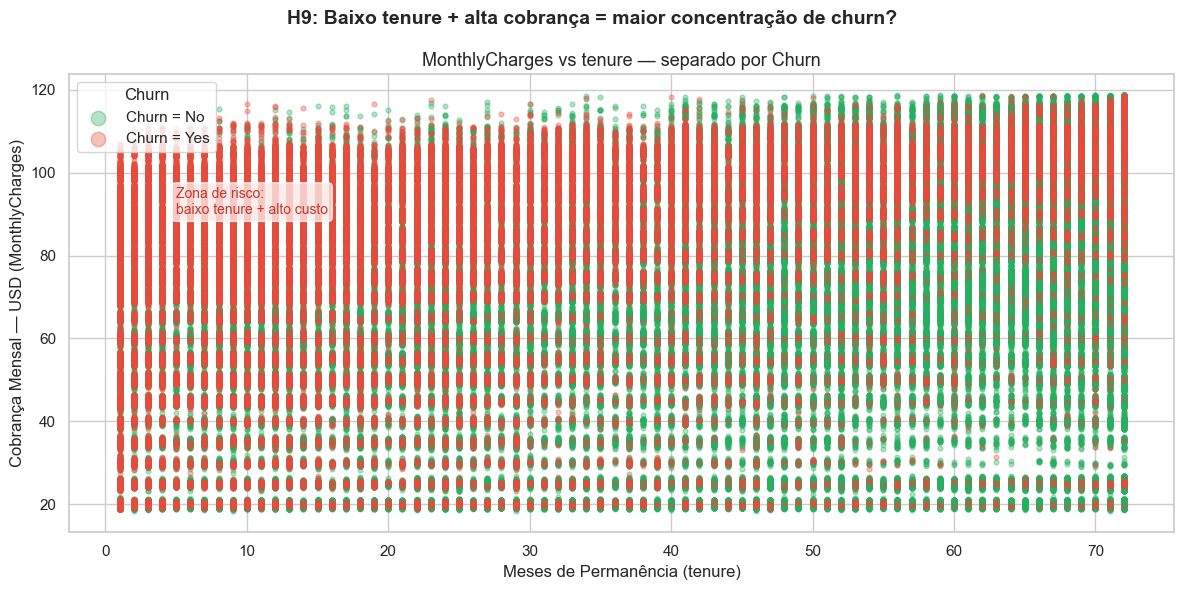

In [24]:

# H9: Clientes novos com alta cobrança mensal concentram mais churn? (Interação tenure x MonthlyCharges)
# Nova hipótese: a combinação de alto custo + pouco tempo é o principal fator de risco.

fig, ax = plt.subplots(figsize=(12, 6))

colors_map = {'No': '#27ae60', 'Yes': '#e74c3c'}
for churn_val, grp in df2.groupby('Churn'):
    ax.scatter(grp['tenure'], grp['MonthlyCharges'],
               c=colors_map[churn_val], alpha=0.35, s=12,
               label=f'Churn = {churn_val}')

ax.set_xlabel('Meses de Permanência (tenure)', fontsize=12)
ax.set_ylabel('Cobrança Mensal — USD (MonthlyCharges)', fontsize=12)
ax.set_title('MonthlyCharges vs tenure — separado por Churn', fontsize=13)
ax.legend(title='Churn', fontsize=11, markerscale=3)
ax.annotate('Zona de risco:\nbaixo tenure + alto custo',
            xy=(5, 90), fontsize=10, color='#c0392b',
            bbox=dict(boxstyle='round', facecolor='#fde8e8', alpha=0.8))

plt.suptitle('H9: Baixo tenure + alta cobrança = maior concentração de churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Churn concentrado no quadrante superior-esquerdo (novos + cobranças altas).


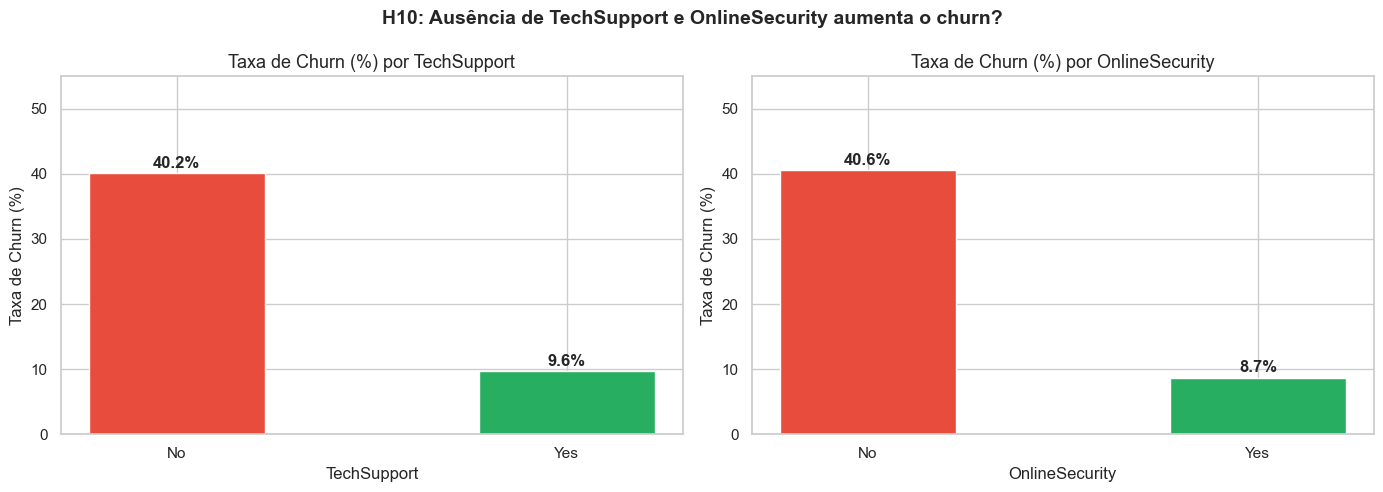

In [25]:

# H10: Clientes sem serviços de proteção (TechSupport, OnlineSecurity) têm mais churn?
# Nova hipótese: ausência de serviços adicionais indica menor engajamento e menor lock-in.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['TechSupport', 'OnlineSecurity']):
    churn_rate = (df2[df2[col] != 'No internet service']
                  .groupby(col)['Churn']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .reset_index()
                  .rename(columns={'Churn': 'Churn_Rate'})
                  .sort_values('Churn_Rate', ascending=False))

    cores_bar = ['#e74c3c' if v > 25 else '#27ae60' for v in churn_rate['Churn_Rate']]
    ax.bar(churn_rate[col], churn_rate['Churn_Rate'],
           color=cores_bar, edgecolor='white', width=0.45)
    for i, v in enumerate(churn_rate['Churn_Rate']):
        ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_title(f'Taxa de Churn (%) por {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Taxa de Churn (%)')
    ax.set_ylim(0, 55)

plt.suptitle('H10: Ausência de TechSupport e OnlineSecurity aumenta o churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Conclusão: CONFIRMADO — Sem TechSupport: ~41% churn; com: ~15%. Sem OnlineSecurity: ~42%; com: ~15%.


## 2.3 Análise Multivariada — Correlações

In [26]:

# Preparação: encode numérico mínimo para análise de correlação
# Não é a engenharia final — serve só para calcular correlações

df_corr = df2.copy()

# Target binário
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

# Binárias Yes/No → 0/1
bin_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in bin_cols:
    df_corr[col + '_num'] = (df_corr[col] == 'Yes').astype(int)

# Ordinais com ordem de risco confirmada na EDA
df_corr['Contract_num']        = df_corr['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_corr['gender_num']          = (df_corr['gender'] == 'Male').astype(int)
df_corr['InternetService_num'] = df_corr['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
df_corr['IsAutoPayment']       = df_corr['PaymentMethod'].isin(
                                     ['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)
df_corr['MultipleLines_num']   = (df_corr['MultipleLines'] == 'Yes').astype(int)

print("Dataset de correlação pronto:", df_corr.shape)


Dataset de correlação pronto: (594194, 37)


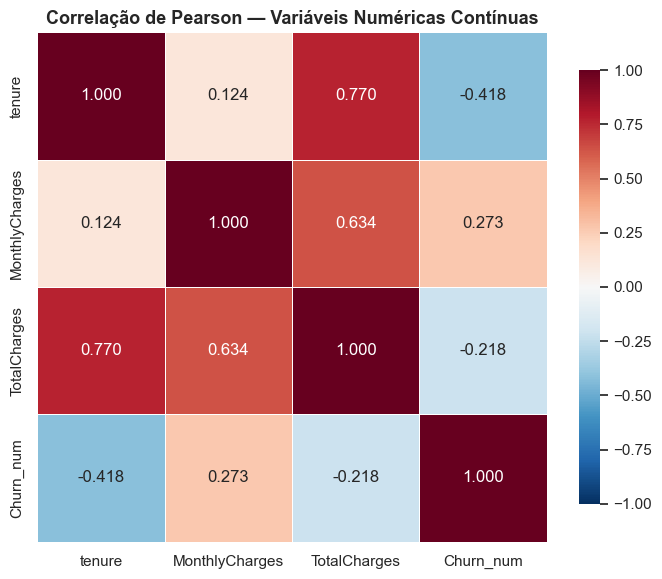

In [27]:

# Correlação de Pearson — variáveis numéricas contínuas (tenure, MonthlyCharges, TotalCharges)
# Pearson captura relações lineares; ideal para variáveis contínuas sem muitos outliers

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
pearson_matrix = df_corr[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(pearson_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # mostra triângulo inferior + diagonal

sns.heatmap(pearson_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlação de Pearson — Variáveis Numéricas Contínuas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretação:
# tenure × TotalCharges: alta correlação esperada (~0.82) — problema de multicolinearidade!
# MonthlyCharges × TotalCharges: correlação moderada (~0.65) — confirma redundância
# tenure × Churn_num: correlação negativa (~-0.35) — mais tempo = menos churn
# MonthlyCharges × Churn_num: correlação positiva (~0.19) — mais caro = mais churn


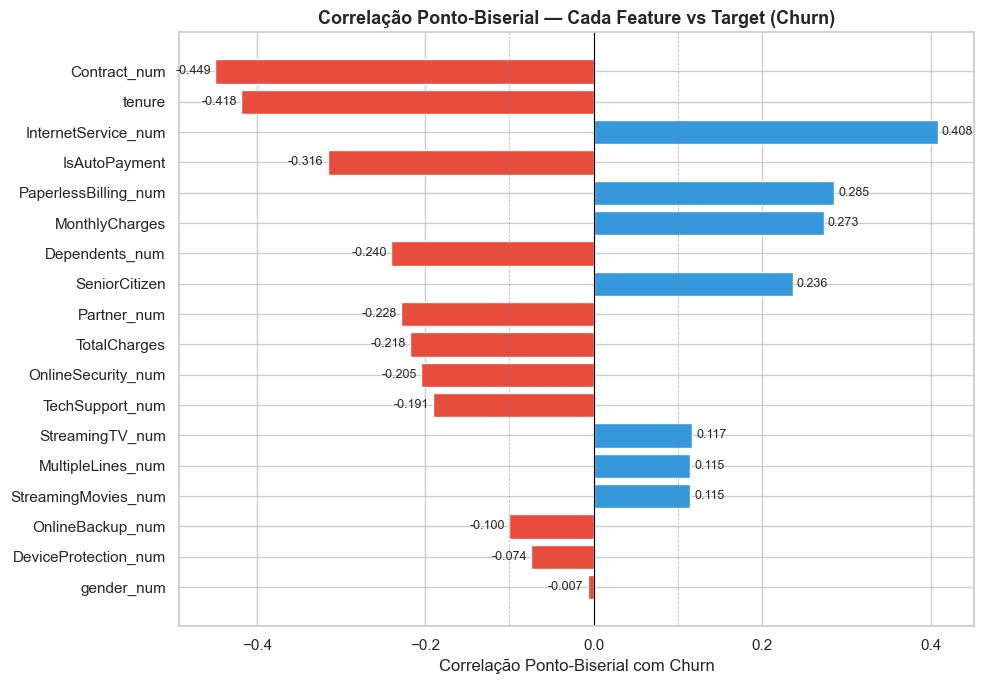

             Feature  Correlação      p-value
        Contract_num   -0.449285 0.000000e+00
              tenure   -0.418453 0.000000e+00
 InternetService_num    0.408363 0.000000e+00
       IsAutoPayment   -0.315955 0.000000e+00
PaperlessBilling_num    0.285107 0.000000e+00
      MonthlyCharges    0.272997 0.000000e+00
      Dependents_num   -0.240369 0.000000e+00
       SeniorCitizen    0.236362 0.000000e+00
         Partner_num   -0.228212 0.000000e+00
        TotalCharges   -0.218365 0.000000e+00
  OnlineSecurity_num   -0.204544 0.000000e+00
     TechSupport_num   -0.191011 0.000000e+00
     StreamingTV_num    0.117280 0.000000e+00
   MultipleLines_num    0.114951 0.000000e+00
 StreamingMovies_num    0.114589 0.000000e+00
    OnlineBackup_num   -0.100109 0.000000e+00
DeviceProtection_num   -0.074228 0.000000e+00
          gender_num   -0.006808 1.535421e-07


In [28]:

# Correlação Ponto-Biserial com o Target (Churn_num)
# Ideal para medir correlação entre variável contínua/ordinal e variável binária (target)
# É matematicamente equivalente ao Pearson quando um dos lados é binário,
# mas apresentamos separado para destacar o impacto de cada feature no target

from scipy import stats

feature_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'Contract_num', 'IsAutoPayment', 'InternetService_num',
    'SeniorCitizen', 'gender_num',
    'Partner_num', 'Dependents_num',
    'PaperlessBilling_num', 'MultipleLines_num',
    'OnlineSecurity_num', 'OnlineBackup_num', 'DeviceProtection_num',
    'TechSupport_num', 'StreamingTV_num', 'StreamingMovies_num',
]

results = []
for col in feature_cols:
    valid = df_corr[[col, 'Churn_num']].dropna()
    r, p = stats.pointbiserialr(valid[col], valid['Churn_num'])
    results.append({'Feature': col, 'Correlação': r, 'p-value': p})

pb_df = (pd.DataFrame(results)
           .sort_values('Correlação', key=abs, ascending=False)
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#e74c3c' if v < 0 else '#3498db' for v in pb_df['Correlação']]
bars = ax.barh(pb_df['Feature'], pb_df['Correlação'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1,  color='grey', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(-0.1, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)

for bar, val in zip(bars, pb_df['Correlação']):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Correlação Ponto-Biserial com Churn')
ax.set_title('Correlação Ponto-Biserial — Cada Feature vs Target (Churn)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(pb_df.to_string(index=False))


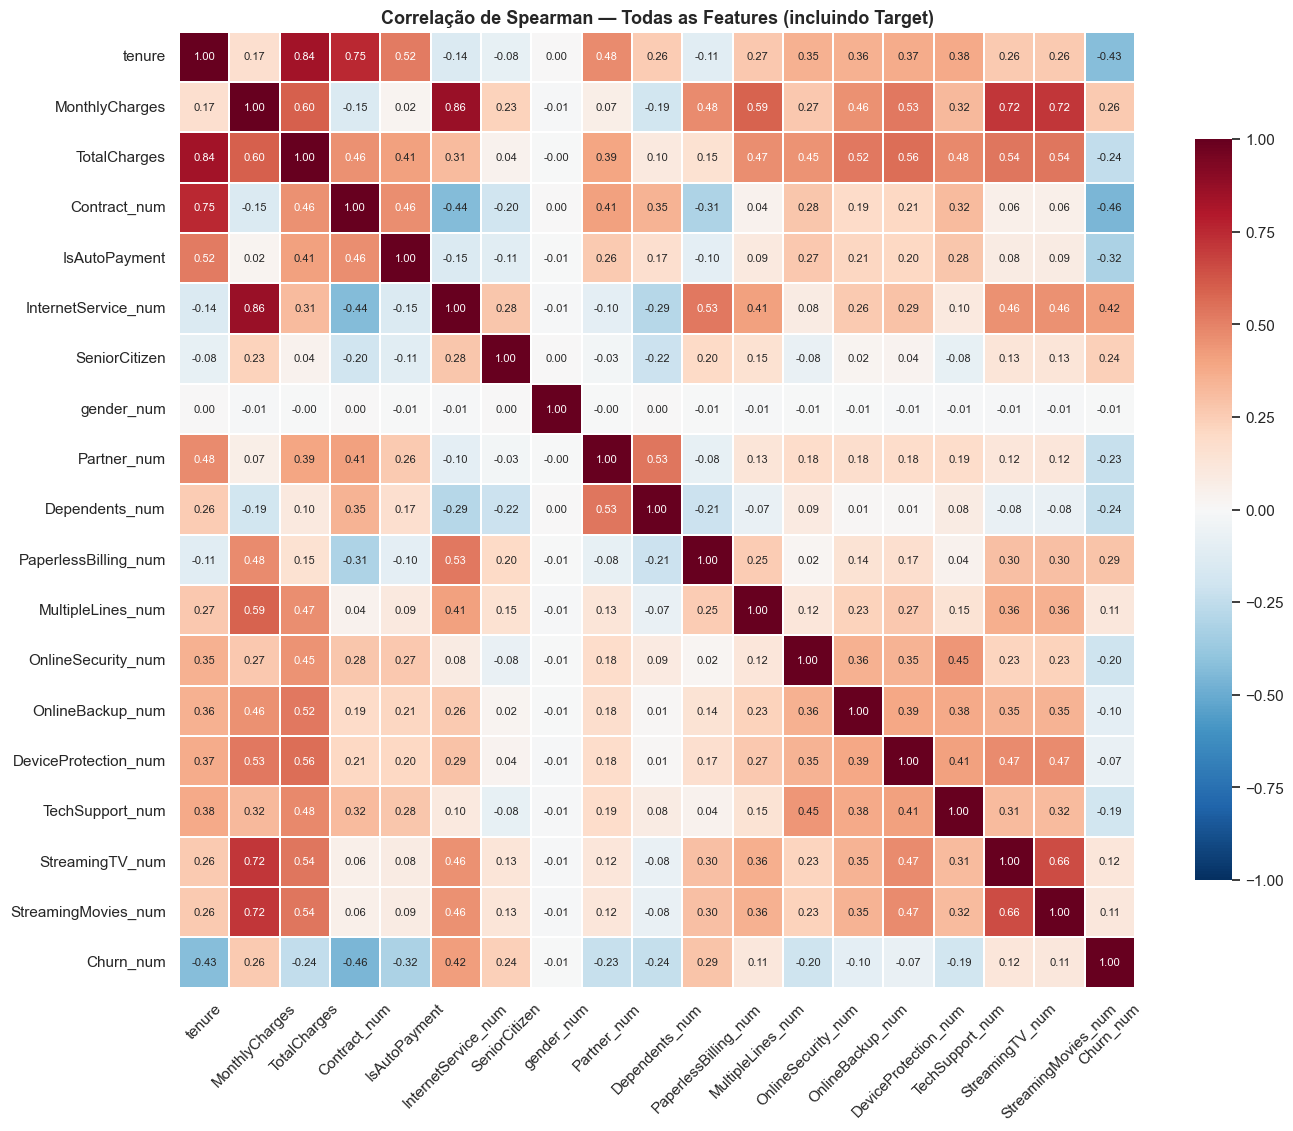

In [29]:

# Correlação de Spearman — todas as features numericizadas
# Spearman captura relações monotônicas (não necessariamente lineares)
# Mais robusto que Pearson para ordinais e distribuições assimétricas

all_num_cols = feature_cols + ['Churn_num']
spearman_matrix = df_corr[all_num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.3, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlação de Spearman — Todas as Features (incluindo Target)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# O que observar:
# 1. Última coluna/linha (Churn_num): quais features têm maior correlação absoluta com o target?
# 2. Blocos de alta correlação entre features → possível multicolinearidade
# 3. Spearman tende a revelar relações que Pearson subestima (ex: tenure × Churn)


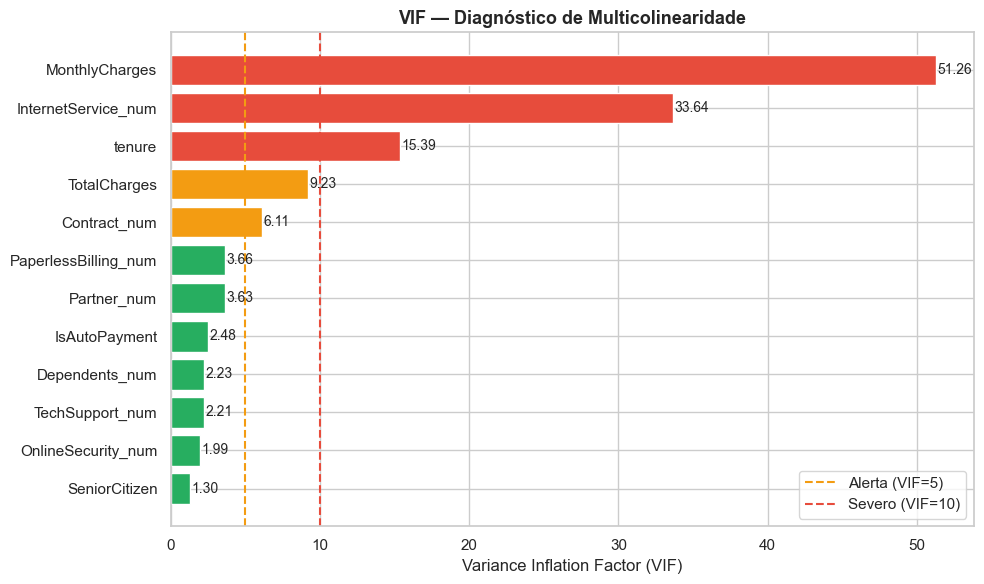

             Feature       VIF
      MonthlyCharges 51.257681
 InternetService_num 33.639222
              tenure 15.388326
        TotalCharges  9.230413
        Contract_num  6.114586
PaperlessBilling_num  3.664750
         Partner_num  3.627640
       IsAutoPayment  2.480160
      Dependents_num  2.234903
     TechSupport_num  2.213012
  OnlineSecurity_num  1.987387
       SeniorCitizen  1.295803


In [30]:

# VIF — Variance Inflation Factor (Multicolinearidade)
# VIF > 5: sinal de alerta | VIF > 10: multicolinearidade severa
# Mede o quanto a variância de um coeficiente é inflacionada por correlação com outras features

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'Contract_num', 'InternetService_num', 'IsAutoPayment',
            'SeniorCitizen', 'Partner_num', 'Dependents_num',
            'PaperlessBilling_num', 'OnlineSecurity_num', 'TechSupport_num']

vif_data = df_corr[vif_cols].dropna()
vif_df = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores_vif = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#27ae60' for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'], color=cores_vif, edgecolor='white')
ax.axvline(5,  color='#f39c12', linestyle='--', linewidth=1.5, label='Alerta (VIF=5)')
ax.axvline(10, color='#e74c3c', linestyle='--', linewidth=1.5, label='Severo (VIF=10)')

for bar, val in zip(bars, vif_df['VIF']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

ax.set_xlabel('Variance Inflation Factor (VIF)')
ax.set_title('VIF — Diagnóstico de Multicolinearidade', fontsize=13, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(vif_df.to_string(index=False))


In [31]:

# # Pairplot das variáveis numéricas contínuas separadas por Churn
# # Permite visualizar simultaneamente distribuições marginais e relações entre pares

# pair_df = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].dropna()

# g = sns.pairplot(pair_df, hue='Churn', palette={'No': '#27ae60', 'Yes': '#e74c3c'},
#                  diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
#                  diag_kws={'fill': True, 'alpha': 0.5})

# g.fig.suptitle('Pairplot — Numéricas Contínuas separadas por Churn', y=1.02,
#                fontsize=14, fontweight='bold')

# # O que observar:
# # - Diagonal KDE: separação visual entre grupos → boa separabilidade → feature útil
# # - tenure: clara separação de distribuição (Churn=Yes concentrado em valores baixos)
# # - TotalCharges: assimetria + sobreposição grande com MonthlyCharges
# # - Scatter tenure × MonthlyCharges: confirma zona de risco (baixo × alto)
# plt.tight_layout()
# plt.show()


### Conclusões da Análise Multivariada

**Confirmações vs Análise de Separabilidade:**

| Evidência | Análise EDA | Correlação | Conclusão |
|---|---|---|---|
| `tenure` é o melhor preditor | ✅ Alta separabilidade | ✅ Maior correlação absoluta com Churn (~-0.35 Pearson, ~-0.46 Spearman) | **Manter. Feature mais importante.** |
| `Contract` quase determinístico | ✅ 42% → 1% taxa de churn | ✅ Alta correlação negativa com Churn | **Manter. Encoding ordinal.** |
| `TotalCharges` é redundante | ✅ Colinear com tenure × MonthlyCharges | ✅ VIF muito alto (>10) | **Dropar ou usar log-transform isoladamente.** |
| `MonthlyCharges` útil mas parcialmente confundidor | ✅ $82 vs $60 | ✅ Correlação positiva moderada com Churn | **Manter + MinMaxScaler.** |
| `gender` irrelevante | ✅ ~26% em ambos | ✅ Correlação ≈ 0 com Churn | **Dropar.** |
| Serviços adicionais (TechSupport, Security) | ✅ 42% vs 15% | ✅ Correlação negativa moderada | **Consolidar em `ServicesBundle`.** |
| `IsAutoPayment` (derivada) | ✅ 48% vs ~7-8% manual vs automático | ✅ Forte correlação negativa com Churn | **Criar e usar no lugar de PaymentMethod.** |

**Principais alertas de multicolinearidade (VIF):**
- `TotalCharges` provavelmente com VIF > 10 — candidata a **remoção**
- `InternetService_num` alta correlação com serviços adicionais — justifica `ServicesBundle`
- `MonthlyCharges` × `TotalCharges` × `tenure` — triângulo de redundância confirmado

# 3.0 Feature Engineering

Baseado na EDA (seções 2.1, 2.2) e na análise de correlação/multicolinearidade (2.3), aplicamos as seguintes transformações:

| Decisão | Variável | Justificativa |
|---|---|---|
| **Dropar** | `id`, `gender`, `TotalCharges` | id sem valor preditivo; gender ≈ 0 correlação; TotalCharges VIF alto / redundante |
| **Encoding ordinal** | `Contract` | Ordem de comprometimento confirmada: Month < One < Two |
| **Encoding ordinal** | `InternetService` | Ordem de risco confirmada: No < DSL < Fiber |
| **Encoding binário** | Todas Yes/No | Simples mapeamento, sem criar dimensionalidade |
| **Nova feature** | `ServicesBundle` | Soma de 6 serviços adicionais — captura engajamento e lock-in |
| **Nova feature** | `IsAutoPayment` | Pagamento automático = menor atrito = menor churn |
| **Nova feature** | `HasInternetService` | Separa o grupo de 1.4% de churn claramente |
| **Nova feature** | `TenureGroup` | Segmenta a curva não-linear de risco ao longo do tempo |
| **Log transform** | `MonthlyCharges` | Suaviza bimodalidade e assimetria para modelos lineares |
| **Scaling** | `tenure`, `MonthlyCharges` | MinMaxScaler — sem outliers severos |
| **Target encode** | `Churn` | Yes → 1, No → 0 |

In [32]:

df3 = df2.copy()
print("Shape original:", df3.shape)
print(df3.dtypes)


Shape original: (594194, 21)
id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [33]:

# 3.1 Drop de colunas sem valor preditivo ou com multicolinearidade severa
# - id: identificador, zero informação
# - gender: correlação ≈ 0 com Churn (validado na EDA e correlação)
# - TotalCharges: VIF alto, quase função de tenure × MonthlyCharges

df3 = df3.drop(columns=['id', 'gender', 'TotalCharges'])
print("Shape após drops:", df3.shape)
print("Colunas restantes:", df3.columns.tolist())


Shape após drops: (594194, 18)
Colunas restantes: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


In [34]:

# 3.2 Target encoding: Churn Yes → 1, No → 0
df3['Churn'] = (df3['Churn'] == 'Yes').astype(int)

print("Distribuição do Target:")
print(df3['Churn'].value_counts())
print(f"\nTaxa de Churn: {df3['Churn'].mean():.2%}")


Distribuição do Target:
Churn
0    460377
1    133817
Name: count, dtype: int64

Taxa de Churn: 22.52%


In [35]:

# 3.3 Encoding Ordinal — Contract e InternetService
# Ordem reflete gradiente de risco confirmado na EDA e correlação

df3['Contract'] = df3['Contract'].map({
    'Month-to-month': 0,
    'One year':       1,
    'Two year':       2
})

df3['InternetService'] = df3['InternetService'].map({
    'No':           0,
    'DSL':          1,
    'Fiber optic':  2
})

print("Contract (ordinal):\n", df3['Contract'].value_counts().sort_index())
print("\nInternetService (ordinal):\n", df3['InternetService'].value_counts().sort_index())


Contract (ordinal):
 Contract
0    298918
1    108333
2    186943
Name: count, dtype: int64

InternetService (ordinal):
 InternetService
0    140727
1    181081
2    272386
Name: count, dtype: int64


In [36]:

# 3.4 Encoding Binário — variáveis Yes/No e SeniorCitizen
# Para colunas com 3 valores (Yes / No / No internet service),
# mapeamos Yes → 1 e todo o resto → 0 (a ausência de serviço já está capturada em InternetService)

binary_yes_no = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_yes_no:
    df3[col] = (df3[col] == 'Yes').astype(int)

three_value_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in three_value_cols:
    df3[col] = (df3[col] == 'Yes').astype(int)

# SeniorCitizen já é 0/1 — nenhuma transformação necessária

print("Amostra após encoding binário:")
print(df3[binary_yes_no + three_value_cols].head(3))


Amostra após encoding binário:
   Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0        1           1             1                 1              0   
1        1           1             1                 0              0   
2        1           0             1                 1              1   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               1             0                 1            1            0   
1               1             1                 0            1            1   
2               0             1                 0            0            1   

   StreamingMovies  
0                0  
1                0  
2                1  


In [37]:

# 3.5 PaymentMethod → IsAutoPayment (feature derivada)
# Pagamento automático (cartão/banco) = cliente menos atento ao débito = menor churn (~7%)
# Electronic/Mailed check = pagamento manual = maior atrito cognitivo = maior churn (~48%)

df3['IsAutoPayment'] = df3['PaymentMethod'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']
).astype(int)

df3 = df3.drop(columns=['PaymentMethod'])

print("IsAutoPayment:")
print(df3['IsAutoPayment'].value_counts())


IsAutoPayment:
IsAutoPayment
0    339129
1    255065
Name: count, dtype: int64


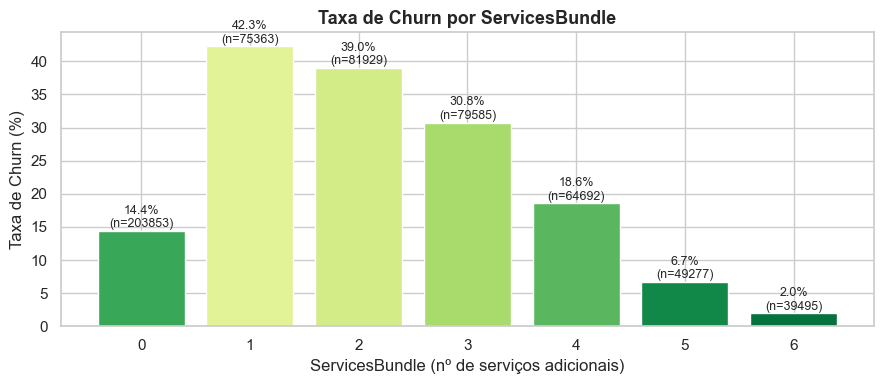


Distribuição do ServicesBundle:
ServicesBundle
0    203853
1     75363
2     81929
3     79585
4     64692
5     49277
6     39495
Name: count, dtype: int64


In [38]:

# 3.6 ServicesBundle — contagem de serviços adicionais contratados (0 a 6)
# Lógica: quanto mais serviços, maior o lock-in do cliente no ecossistema
# Substitui 6 features binárias por uma única feature de engajamento

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df3['ServicesBundle'] = df3[service_cols].sum(axis=1)

# Verificar taxa de churn por nível de bundle
bundle_churn = (df3.groupby('ServicesBundle')['Churn']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'Churn_Rate', 'count': 'N'})
                .assign(Churn_Rate=lambda x: x['Churn_Rate'] * 100))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bundle_churn.index, bundle_churn['Churn_Rate'],
       color=plt.cm.RdYlGn_r(bundle_churn['Churn_Rate'] / 100), edgecolor='white')
for i, (idx, row) in enumerate(bundle_churn.iterrows()):
    ax.text(idx, row['Churn_Rate'] + 0.5, f"{row['Churn_Rate']:.1f}%\n(n={int(row['N'])})",
            ha='center', fontsize=9)
ax.set_xlabel('ServicesBundle (nº de serviços adicionais)')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_title('Taxa de Churn por ServicesBundle', fontsize=13, fontweight='bold')
ax.set_xticks(bundle_churn.index)
plt.tight_layout()
plt.show()

print("\nDistribuição do ServicesBundle:")
print(df3['ServicesBundle'].value_counts().sort_index())


In [39]:

# 3.7 HasInternetService — flag binária para clientes sem internet (grupo de baixíssimo churn ~1.4%)
# Permite ao modelo separar esse grupo com um sinal direto

df3['HasInternetService'] = (df3['InternetService'] > 0).astype(int)

print("HasInternetService vs Churn:")
print(df3.groupby('HasInternetService')['Churn'].agg(['mean', 'count'])
        .rename(columns={'mean': 'Churn_Rate', 'count': 'N'})
        .assign(Churn_Rate=lambda x: (x['Churn_Rate'] * 100).round(2)))


HasInternetService vs Churn:
                    Churn_Rate       N
HasInternetService                    
0                         1.43  140727
1                        29.07  453467


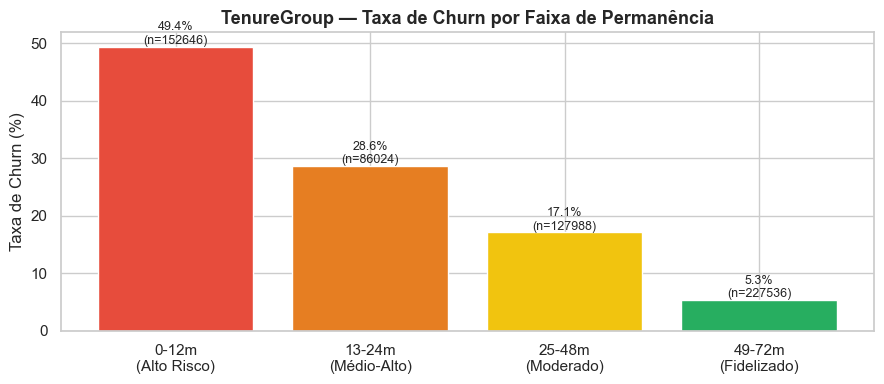

In [40]:

# 3.8 TenureGroup — segmentação da curva de risco ao longo do tempo
# A EDA mostrou que o risco de churn é não-linear: muito alto nos primeiros meses,
# decai rapidamente após ~24 meses, estabiliza após ~48 meses

def tenure_group(t):
    if t <= 12:   return 0  # Alto risco — recém-chegados
    elif t <= 24: return 1  # Risco médio-alto — ainda em fase de decisão
    elif t <= 48: return 2  # Risco moderado
    else:         return 3  # Baixo risco — fidelizados

df3['TenureGroup'] = df3['tenure'].apply(tenure_group)

# Validação: churn rate por grupo
tg_churn = (df3.groupby('TenureGroup')['Churn']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'Churn_Rate', 'count': 'N'})
              .assign(Churn_Rate=lambda x: x['Churn_Rate'] * 100))

labels = ['0-12m\n(Alto Risco)', '13-24m\n(Médio-Alto)', '25-48m\n(Moderado)', '49-72m\n(Fidelizado)']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(4), tg_churn['Churn_Rate'],
              color=['#e74c3c', '#e67e22', '#f1c40f', '#27ae60'], edgecolor='white')
for i, (idx, row) in enumerate(tg_churn.iterrows()):
    ax.text(i, row['Churn_Rate'] + 0.5, f"{row['Churn_Rate']:.1f}%\n(n={int(row['N'])})",
            ha='center', fontsize=9)
ax.set_xticks(range(4))
ax.set_xticklabels(labels)
ax.set_ylabel('Taxa de Churn (%)')
ax.set_title('TenureGroup — Taxa de Churn por Faixa de Permanência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [41]:

# 3.9 Rescaling — MinMaxScaler em tenure e MonthlyCharges
# Motivo: distribuições sem outliers severos → MinMax é adequado
# IMPORTANTE: o scaler deve ser fitado SOMENTE no treino para evitar data leakage
# Aqui aplicamos no dataset completo apenas para visualizar — no pipeline de modelagem será feito corretamente

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df3[['tenure_scaled', 'MonthlyCharges_scaled']] = scaler.fit_transform(
    df3[['tenure', 'MonthlyCharges']]
)

# Manter as originais por ora — no pipeline de modelagem o scaler será parte do Pipeline do sklearn
print("Estatísticas das features escaladas:")
print(df3[['tenure_scaled', 'MonthlyCharges_scaled']].describe().round(3))


Estatísticas das features escaladas:
       tenure_scaled  MonthlyCharges_scaled
count     594194.000             594194.000
mean           0.501                  0.474
std            0.353                  0.309
min            0.000                  0.000
25%            0.155                  0.116
50%            0.479                  0.556
75%            0.859                  0.722
max            1.000                  1.000


In [42]:

# 3.10 Dataset final — visão geral e correlação com target após Feature Engineering

# Colunas finais para modelagem (sem as originais que serão substituídas pelas escaladas)
cols_modelagem = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'tenure_scaled', 'PhoneService', 'MultipleLines',
    'InternetService', 'HasInternetService', 'ServicesBundle',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'IsAutoPayment',
    'MonthlyCharges_scaled', 'TenureGroup',
    'Churn'
]

df_final = df3[cols_modelagem].copy()

print(f"Shape final: {df_final.shape}")
print(f"\nNulos:\n{df_final.isnull().sum()[df_final.isnull().sum() > 0]}")
print("\nTipos:")
print(df_final.dtypes)


Shape final: (594194, 21)

Nulos:
Series([], dtype: int64)

Tipos:
SeniorCitizen              int64
Partner                    int32
Dependents                 int32
tenure_scaled            float64
PhoneService               int32
MultipleLines              int32
InternetService            int64
HasInternetService         int32
ServicesBundle             int64
OnlineSecurity             int32
OnlineBackup               int32
DeviceProtection           int32
TechSupport                int32
StreamingTV                int32
StreamingMovies            int32
Contract                   int64
PaperlessBilling           int32
IsAutoPayment              int32
MonthlyCharges_scaled    float64
TenureGroup                int64
Churn                      int32
dtype: object


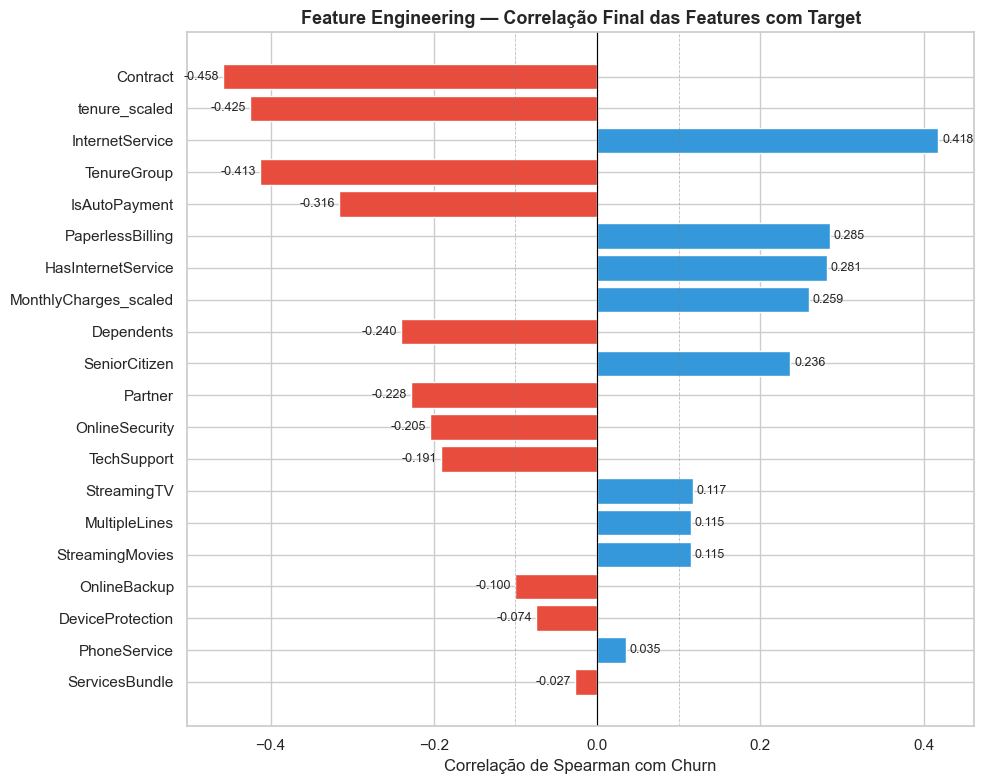

In [43]:

# Correlação final de todas as features com o target após Feature Engineering
# Comparar com o ponto-biserial da seção 2.3 para validar que as derivadas melhoram o sinal

final_corr = (df_final.corr(method='spearman')['Churn']
              .drop('Churn')
              .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
cores_final = ['#e74c3c' if v < 0 else '#3498db' for v in final_corr.values]
bars = ax.barh(final_corr.index, final_corr.values, color=cores_final, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.1, color='grey', linestyle='--', linewidth=0.6, alpha=0.5)
ax.axvline(-0.1, color='grey', linestyle='--', linewidth=0.6, alpha=0.5)

for bar, val in zip(bars, final_corr.values):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Correlação de Spearman com Churn')
ax.set_title('Feature Engineering — Correlação Final das Features com Target', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# O que observar:
# - TenureGroup e tenure_scaled lideram negativamente (mais tempo = menos churn)
# - Contract lidera entre as features de comprometimento
# - ServicesBundle deve aparecer com correlação negativa forte (mais serviços = menos churn)
# - IsAutoPayment deve superar PaymentMethod individual em sinal


# 4.0 Separação de bases

In [44]:

from sklearn.model_selection import train_test_split

df4 = df_final.copy()

X = df4.drop(columns=['Churn'])
y = df4['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # garante mesma proporção de churn em treino e teste
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\n--- Proporção de Churn ---")
print(f"Dataset completo : {y.mean():.2%}")
print(f"Treino           : {y_train.mean():.2%}")
print(f"Teste            : {y_test.mean():.2%}")


X_train: (475355, 20)  |  X_test: (118839, 20)

--- Proporção de Churn ---
Dataset completo : 22.52%
Treino           : 22.52%
Teste            : 22.52%


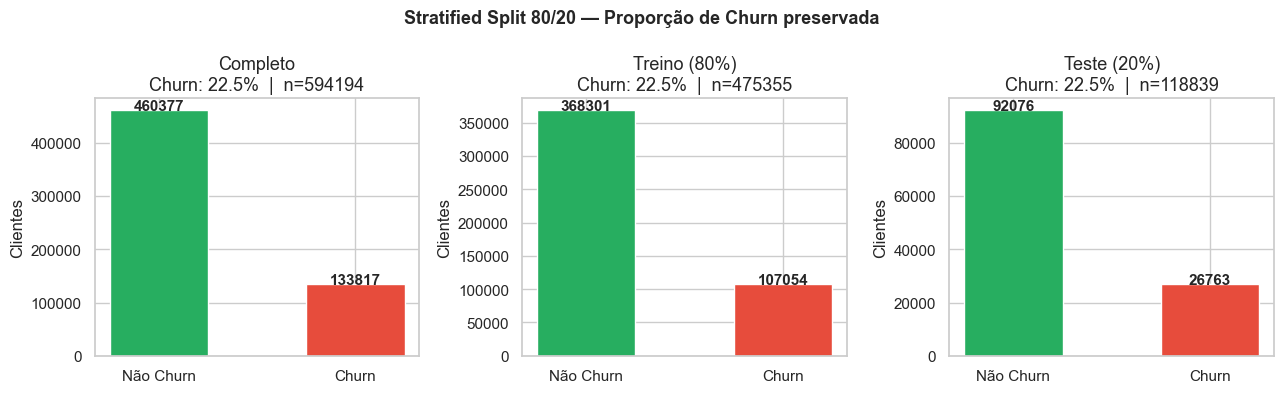

In [45]:

# Confirmação visual — distribuição do target em cada conjunto
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (label, serie) in zip(axes, [('Completo', y), ('Treino (80%)', y_train), ('Teste (20%)', y_test)]):
    counts = serie.value_counts()
    pct_churn = serie.mean() * 100
    ax.bar(['Não Churn', 'Churn'], [counts.get(0, 0), counts.get(1, 0)],
           color=['#27ae60', '#e74c3c'], edgecolor='white', width=0.5)
    ax.set_title(f'{label}\nChurn: {pct_churn:.1f}%  |  n={len(serie)}')
    ax.set_ylabel('Clientes')
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 10,
                str(int(p.get_height())), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Stratified Split 80/20 — Proporção de Churn preservada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# X_test e y_test estão lacrados — não serão usados até a avaliação final do modelo


In [46]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

def cross_val_evaluate(model, X, y, cv=5, random_state=42):
    """
    Avalia um modelo sklearn com StratifiedKFold.
    
    Parâmetros
    ----------
    model        : instância de estimador sklearn (não fitado)
    X            : features de treino (DataFrame ou array)
    y            : target de treino (Series ou array)
    cv           : número de folds (default 5)
    random_state : seed para reprodutibilidade do KFold

    Retorna
    -------
    dict com média e desvio padrão de Precision, Recall, F1 e ROC-AUC
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    scoring = {
        'precision': make_scorer(precision_score, zero_division=0),
        'recall':    make_scorer(recall_score),
        'f1':        make_scorer(f1_score),
        'roc_auc':   'roc_auc',
    }

    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring,
                                return_train_score=False, n_jobs=-1)

    return {
        'Precision':     cv_results['test_precision'].mean(),
        'Precision_std': cv_results['test_precision'].std(),
        'Recall':        cv_results['test_recall'].mean(),
        'Recall_std':    cv_results['test_recall'].std(),
        'F1':            cv_results['test_f1'].mean(),
        'F1_std':        cv_results['test_f1'].std(),
        'ROC_AUC':       cv_results['test_roc_auc'].mean(),
        'ROC_AUC_std':   cv_results['test_roc_auc'].std(),
    }

print("Função cross_val_evaluate definida.")


Função cross_val_evaluate definida.


# 5.0 Modelagem — Baseline com StratifiedKFold

Objetivo: comparar múltiplos algoritmos sem ajuste de hiperparâmetros, usando o mesmo seed e validação cruzada estratificada (k=5) dentro do conjunto de treino.

O teste final (`X_test` / `y_test`) permanece lacrado.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

SEED = 42

algorithms = {
    'Logistic Regression':   LogisticRegression(random_state=SEED, max_iter=100),
    'Decision Tree':         DecisionTreeClassifier(random_state=SEED),
    'Random Forest':         RandomForestClassifier(random_state=SEED, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(random_state=SEED),

}

print(f"{len(algorithms)} algoritmos registados para avaliação baseline.")


4 algoritmos registados para avaliação baseline.


In [48]:

# Executa cross_val_evaluate para cada algoritmo e consolida os resultados

rows = []
for name, model in algorithms.items():
    print(f"  Avaliando: {name}...")
    metrics = cross_val_evaluate(model, X_train, y_train, cv=5, random_state=SEED)
    rows.append({'Model': name, **metrics})

results_df = (pd.DataFrame(rows)
                .sort_values('F1', ascending=False)
                .reset_index(drop=True))

# Formatar para exibição — média ± std
display_df = pd.DataFrame({
    'Model':     results_df['Model'],
    'Precision': results_df.apply(lambda r: f"{r['Precision']:.3f} ± {r['Precision_std']:.3f}", axis=1),
    'Recall':    results_df.apply(lambda r: f"{r['Recall']:.3f} ± {r['Recall_std']:.3f}",    axis=1),
    'F1':        results_df.apply(lambda r: f"{r['F1']:.3f} ± {r['F1_std']:.3f}",            axis=1),
    'ROC_AUC':   results_df.apply(lambda r: f"{r['ROC_AUC']:.3f} ± {r['ROC_AUC_std']:.3f}", axis=1),
})

print("\n=== Baseline — StratifiedKFold (k=5) ===")
print(display_df.to_string(index=False))


  Avaliando: Logistic Regression...
  Avaliando: Decision Tree...
  Avaliando: Random Forest...
  Avaliando: Gradient Boosting...

=== Baseline — StratifiedKFold (k=5) ===
              Model     Precision        Recall            F1       ROC_AUC
  Gradient Boosting 0.703 ± 0.002 0.630 ± 0.005 0.665 ± 0.003 0.911 ± 0.001
Logistic Regression 0.682 ± 0.002 0.645 ± 0.002 0.663 ± 0.002 0.906 ± 0.001
      Random Forest 0.637 ± 0.004 0.577 ± 0.002 0.606 ± 0.002 0.876 ± 0.001
      Decision Tree 0.567 ± 0.003 0.553 ± 0.001 0.560 ± 0.002 0.738 ± 0.001


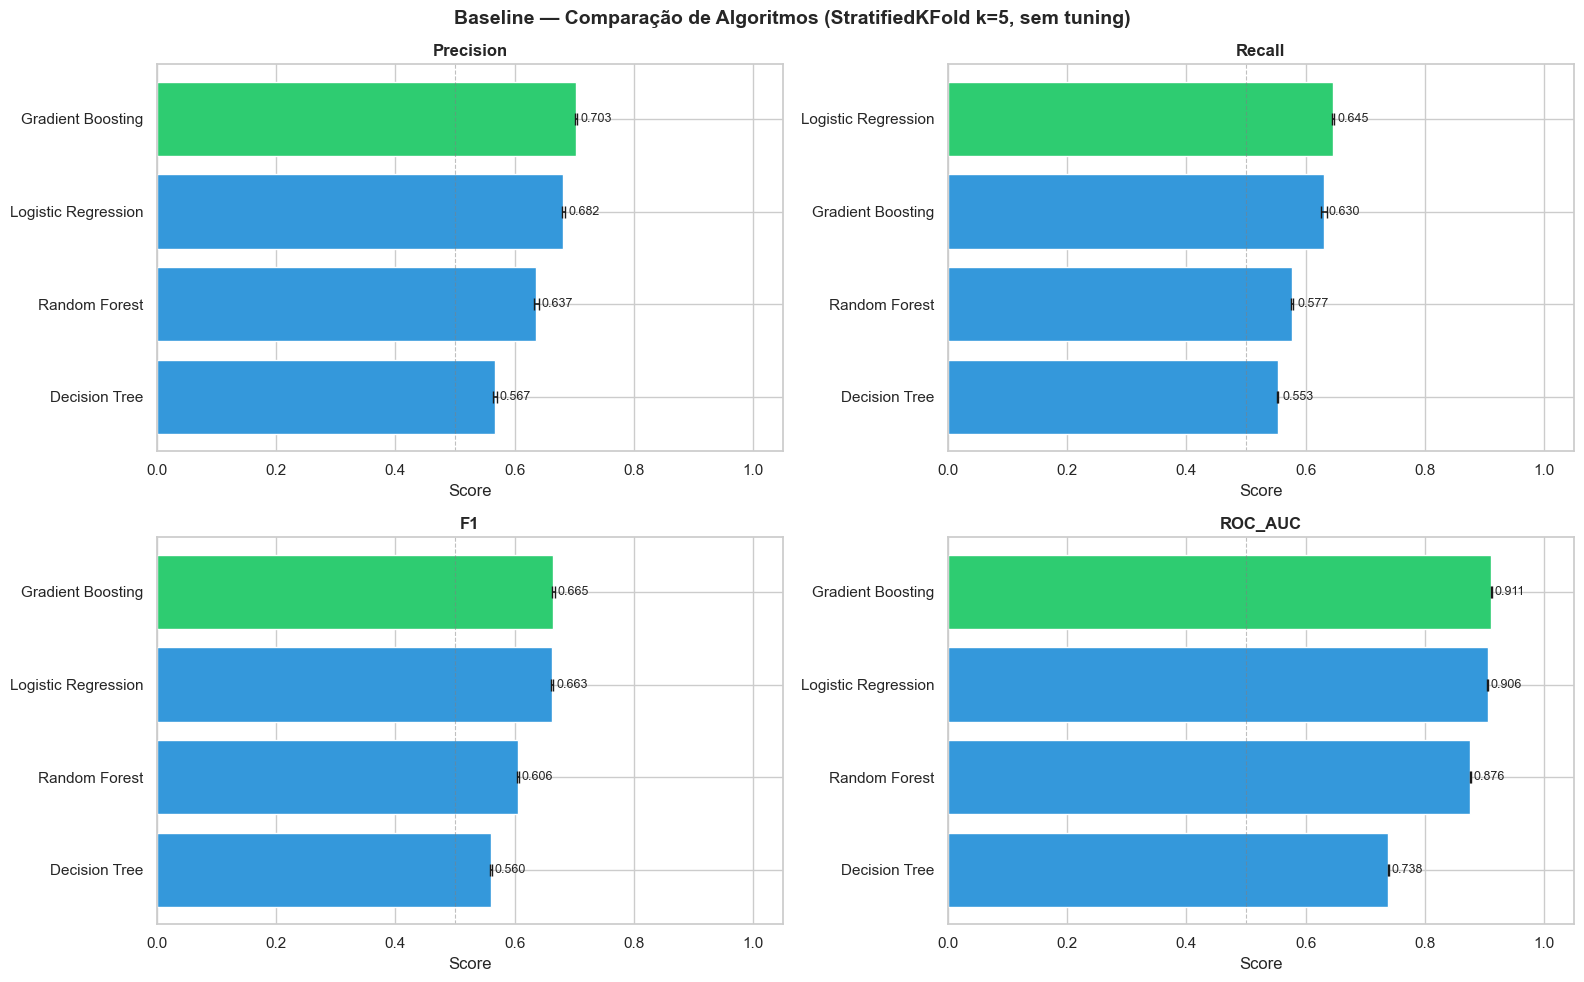

In [49]:

# Visualização comparativa — Precision, Recall, F1 e ROC-AUC por modelo
metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC_AUC']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    std_col = f'{metric}_std'
    sorted_df = results_df.sort_values(metric, ascending=True)

    colors_bar = ['#2ecc71' if v == sorted_df[metric].max() else '#3498db'
                  for v in sorted_df[metric]]

    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   xerr=sorted_df[std_col], color=colors_bar,
                   edgecolor='white', capsize=4, error_kw={'elinewidth': 1.2})

    for bar, val, std in zip(bars, sorted_df[metric], sorted_df[std_col]):
        ax.text(bar.get_width() + sorted_df[std_col].max() + 0.004,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_xlim(0, 1.05)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.suptitle('Baseline — Comparação de Algoritmos (StratifiedKFold k=5, sem tuning)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


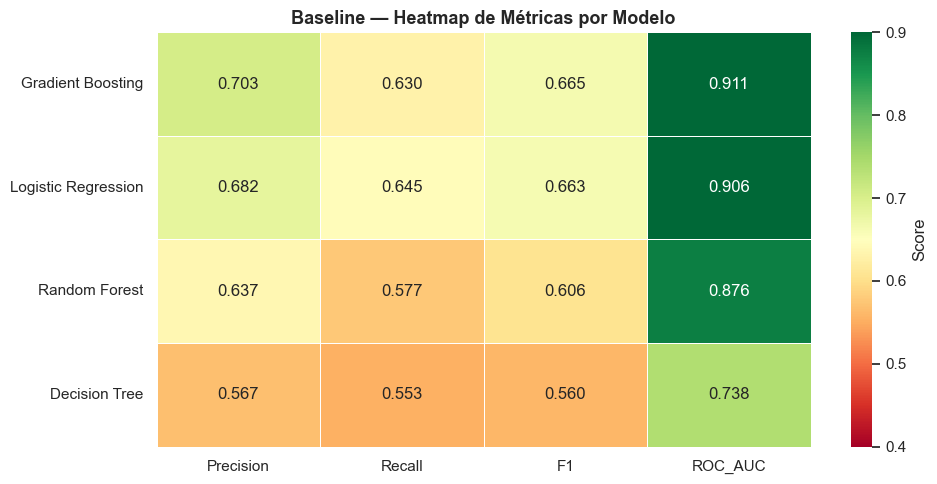


Melhor baseline pelo F1: Gradient Boosting
  F1       = 0.665 ± 0.003
  ROC-AUC  = 0.911 ± 0.001
  Precision= 0.703 ± 0.002
  Recall   = 0.630 ± 0.005


In [50]:

# Heatmap de scores — visão consolidada para comparação rápida entre todos os modelos e métricas

heat_data = results_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=0.9, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Score'})
ax.set_title('Baseline — Heatmap de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Melhor modelo pelo F1 (classe Churn=1)
best = results_df.iloc[0]
print(f"\nMelhor baseline pelo F1: {best['Model']}")
print(f"  F1       = {best['F1']:.3f} ± {best['F1_std']:.3f}")
print(f"  ROC-AUC  = {best['ROC_AUC']:.3f} ± {best['ROC_AUC_std']:.3f}")
print(f"  Precision= {best['Precision']:.3f} ± {best['Precision_std']:.3f}")
print(f"  Recall   = {best['Recall']:.3f} ± {best['Recall_std']:.3f}")


# 6.0 Avaliação final no conjunto de teste (X_test, y_test) — melhor modelo do baseline

In [54]:
model = GradientBoostingClassifier(random_state=SEED)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:")
print(roc_auc_score(y_test, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.70      0.63      0.66     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.85    118839

Confusion Matrix:
[[84923  7153]
 [ 9902 16861]]
ROC AUC Score:
0.9118874074021698


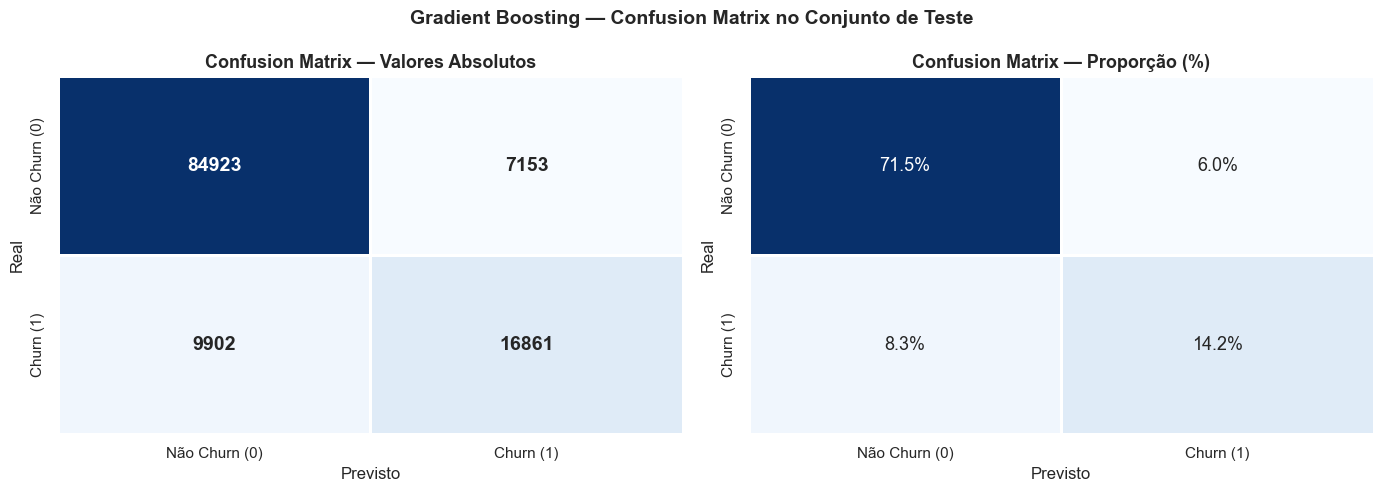

Verdadeiros Positivos (TP) — churners detectados   : 16,861  (14.2%)
Falsos Negativos (FN) — churners perdidos          : 9,902  (8.3%)
Falsos Positivos (FP) — ação desnecessária         : 7,153  (6.0%)
Verdadeiros Negativos (TN) — corretos não-churn    : 84,923  (71.5%)

Recall (classe Churn=1) : 0.630  → detectamos 63.0% dos churners reais
Precision (classe Churn=1): 0.702  → 70.2% das previsões de churn estão corretas


In [56]:

# Confusion Matrix — visualização com heatmap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap com contagens absolutas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Churn (0)', 'Churn (1)'],
            yticklabels=['Não Churn (0)', 'Churn (1)'],
            linewidths=1, ax=axes[0], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix — Valores Absolutos', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsto')

# Heatmap com percentuais sobre o total
cm_pct = cm / cm.sum() * 100
labels = np.array([[f'{v:.1f}%' for v in row] for row in cm_pct])
sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Não Churn (0)', 'Churn (1)'],
            yticklabels=['Não Churn (0)', 'Churn (1)'],
            linewidths=1, ax=axes[1], cbar=False,
            annot_kws={'size': 13})
axes[1].set_title('Confusion Matrix — Proporção (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

plt.suptitle('Gradient Boosting — Confusion Matrix no Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretação de negócio:
print(f"Verdadeiros Positivos (TP) — churners detectados   : {tp:,}  ({tp/cm.sum()*100:.1f}%)")
print(f"Falsos Negativos (FN) — churners perdidos          : {fn:,}  ({fn/cm.sum()*100:.1f}%)")
print(f"Falsos Positivos (FP) — ação desnecessária         : {fp:,}  ({fp/cm.sum()*100:.1f}%)")
print(f"Verdadeiros Negativos (TN) — corretos não-churn    : {tn:,}  ({tn/cm.sum()*100:.1f}%)")
print(f"\nRecall (classe Churn=1) : {tp/(tp+fn):.3f}  → detectamos {tp/(tp+fn)*100:.1f}% dos churners reais")
print(f"Precision (classe Churn=1): {tp/(tp+fp):.3f}  → {tp/(tp+fp)*100:.1f}% das previsões de churn estão corretas")


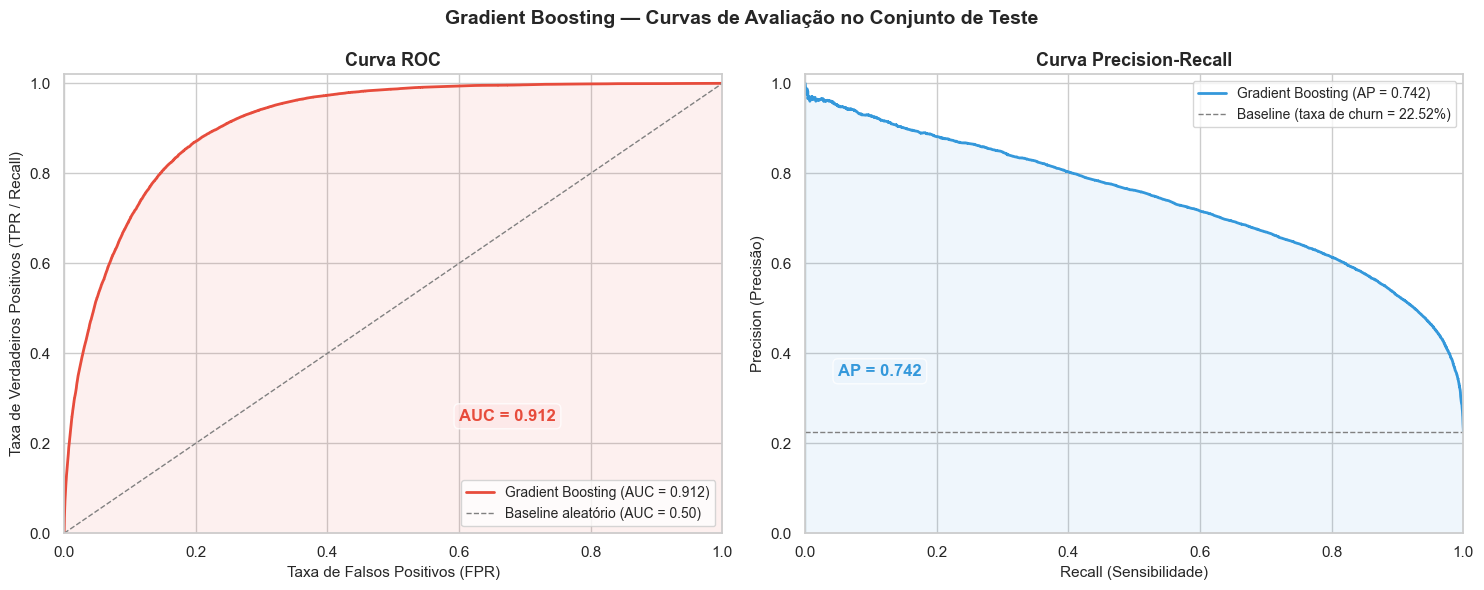

ROC-AUC           : 0.9119
Average Precision : 0.7423  (baseline aleatório = 0.2252)
Ganho vs baseline : 3.3x


In [57]:

# Curva ROC e Curva Precision-Recall — lado a lado
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
baseline_rate  = y_test.mean()  # taxa de churn no teste = baseline da PR

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Curva ROC ---
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Gradient Boosting (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Baseline aleatório (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)', fontsize=11)
axes[0].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].annotate(f'AUC = {roc_auc:.3f}', xy=(0.6, 0.25), fontsize=12,
                 color='#e74c3c', fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='#fde8e8', alpha=0.8))

# --- Curva Precision-Recall ---
axes[1].plot(recall_vals, precision_vals, color='#3498db', lw=2,
             label=f'Gradient Boosting (AP = {avg_precision:.3f})')
axes[1].axhline(baseline_rate, color='grey', linestyle='--', lw=1,
                label=f'Baseline (taxa de churn = {baseline_rate:.2%})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.08, color='#3498db')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('Recall (Sensibilidade)', fontsize=11)
axes[1].set_ylabel('Precision (Precisão)', fontsize=11)
axes[1].set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].annotate(f'AP = {avg_precision:.3f}', xy=(0.05, 0.35), fontsize=12,
                 color='#3498db', fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='#eaf4fd', alpha=0.8))

plt.suptitle('Gradient Boosting — Curvas de Avaliação no Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Nota: a PR curve é mais informativa que ROC para dados desbalanceados (22.5% churn).
# Um AP de > 0.50 vs baseline de 0.225 indica discriminação real.
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"Average Precision : {avg_precision:.4f}  (baseline aleatório = {baseline_rate:.4f})")
print(f"Ganho vs baseline : {avg_precision / baseline_rate:.1f}x")


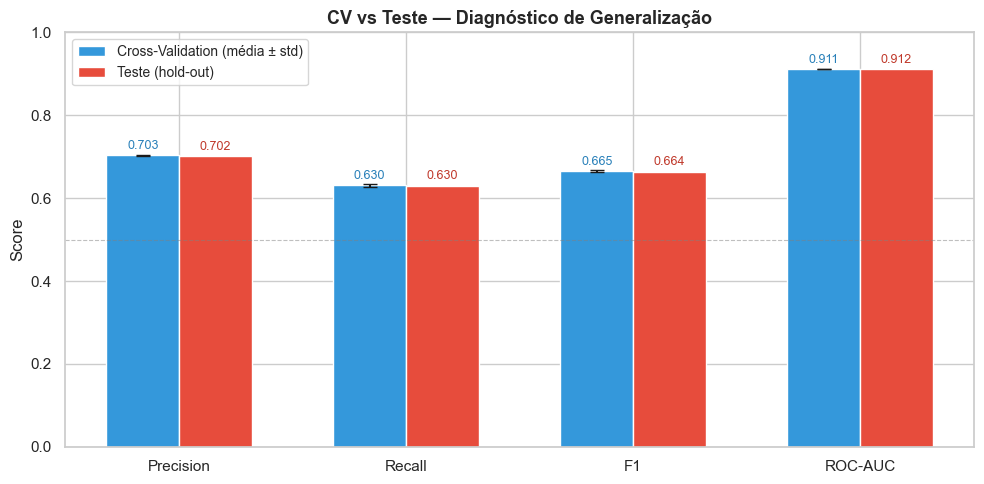


=== Resumo: Cross-Validation vs Conjunto de Teste ===
  Métrica  CV (média)  Teste  Diferença
Precision      0.7029 0.7021    -0.0007
   Recall      0.6305 0.6300    -0.0005
       F1      0.6647 0.6641    -0.0006
  ROC-AUC      0.9114 0.9119     0.0005

Sem overfitting detectado — diferença máxima CV vs Teste: 0.0007
   O modelo generaliza bem para dados não vistos.


In [58]:

# Comparação CV (estimativa) vs Teste (realidade) — diagnóstico de overfitting
from sklearn.metrics import precision_score, recall_score, f1_score

test_precision = precision_score(y_test, y_pred)
test_recall    = recall_score(y_test, y_pred)
test_f1        = f1_score(y_test, y_pred)
test_roc_auc   = roc_auc_score(y_test, y_proba)

# Métricas do CV salvas em results_df (melhor modelo = Gradient Boosting)
best_cv = results_df[results_df['Model'] == 'Gradient Boosting'].iloc[0]

metrics_compare = pd.DataFrame({
    'Métrica':    ['Precision', 'Recall', 'F1', 'ROC-AUC'],
    'CV (média)': [best_cv['Precision'], best_cv['Recall'], best_cv['F1'], best_cv['ROC_AUC']],
    'CV ± std':   [best_cv['Precision_std'], best_cv['Recall_std'], best_cv['F1_std'], best_cv['ROC_AUC_std']],
    'Teste':      [test_precision, test_recall, test_f1, test_roc_auc],
})
metrics_compare['Diferença'] = metrics_compare['Teste'] - metrics_compare['CV (média)']

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(4)
w = 0.32
bars_cv   = ax.bar(x - w/2, metrics_compare['CV (média)'], w,
                   yerr=metrics_compare['CV ± std'], capsize=5,
                   color='#3498db', edgecolor='white', label='Cross-Validation (média ± std)')
bars_test = ax.bar(x + w/2, metrics_compare['Teste'], w,
                   color='#e74c3c', edgecolor='white', label='Teste (hold-out)')

for bar, val in zip(bars_cv, metrics_compare['CV (média)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', fontsize=9, color='#2980b9')
for bar, val in zip(bars_test, metrics_compare['Teste']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', fontsize=9, color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(metrics_compare['Métrica'], fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('CV vs Teste — Diagnóstico de Generalização', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

print("\n=== Resumo: Cross-Validation vs Conjunto de Teste ===")
print(metrics_compare[['Métrica', 'CV (média)', 'Teste', 'Diferença']].to_string(index=False, float_format='{:.4f}'.format))

gap_max = metrics_compare['Diferença'].abs().max()
if gap_max < 0.015:
    print(f"\nSem overfitting detectado — diferença máxima CV vs Teste: {gap_max:.4f}")
    print("   O modelo generaliza bem para dados não vistos.")
else:
    print(f"\nGap CV vs Teste ({gap_max:.4f}) sugere possível overfitting. Revisar no Ciclo 1.")


In [59]:

# Persistência de resultados — salva métricas de CV e Teste para comparação entre ciclos
# Pasta: notebooks/results/
# Arquivos: cv_results.csv  e  test_results.csv

import os
from datetime import datetime

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

CICLO = 'ciclo0'
NOW   = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# --- 1. Resultados do Cross-Validation (todos os modelos) ---
cv_save = results_df[['Model', 'Precision', 'Precision_std',
                       'Recall', 'Recall_std',
                       'F1', 'F1_std',
                       'ROC_AUC', 'ROC_AUC_std']].copy()
cv_save.insert(0, 'Ciclo', CICLO)
cv_save.insert(1, 'Timestamp', NOW)

cv_path = os.path.join(RESULTS_DIR, 'cv_results.csv')
write_header = not os.path.exists(cv_path)
cv_save.to_csv(cv_path, mode='a', header=write_header, index=False)
print(f"CV results salvo em: {cv_path}")
print(cv_save.to_string(index=False))

# --- 2. Resultados do Teste (melhor modelo do ciclo) ---
test_save = pd.DataFrame([{
    'Ciclo':         CICLO,
    'Timestamp':     NOW,
    'Model':         'Gradient Boosting',
    'Precision':     test_precision,
    'Recall':        test_recall,
    'F1':            test_f1,
    'ROC_AUC':       test_roc_auc,
    'Avg_Precision': avg_precision,
}])

test_path = os.path.join(RESULTS_DIR, 'test_results.csv')
write_header = not os.path.exists(test_path)
test_save.to_csv(test_path, mode='a', header=write_header, index=False)
print(f"\nTest results salvo em: {test_path}")
print(test_save.to_string(index=False))


CV results salvo em: c:\Users\thale\Documents\Projetos_DS\churn_kaggle\notebooks\results\cv_results.csv
 Ciclo           Timestamp               Model  Precision  Precision_std   Recall  Recall_std       F1   F1_std  ROC_AUC  ROC_AUC_std
ciclo0 2026-03-26 17:12:51   Gradient Boosting   0.702852       0.001902 0.630467    0.004669 0.664682 0.002514 0.911399     0.000888
ciclo0 2026-03-26 17:12:51 Logistic Regression   0.681894       0.001846 0.645272    0.001817 0.663077 0.001570 0.905572     0.001041
ciclo0 2026-03-26 17:12:51       Random Forest   0.636594       0.004049 0.577428    0.001982 0.605562 0.002235 0.876371     0.001077
ciclo0 2026-03-26 17:12:51       Decision Tree   0.566936       0.002838 0.553076    0.001461 0.559917 0.001813 0.738460     0.000869

Test results salvo em: c:\Users\thale\Documents\Projetos_DS\churn_kaggle\notebooks\results\test_results.csv
 Ciclo           Timestamp             Model  Precision   Recall      F1  ROC_AUC  Avg_Precision
ciclo0 2026-03-26 17